# SAPN2022 Aggregate Curtailment Plots

This notebook builds multiple aggregate plots

It is organised as simple plot sections so the same pattern can be reused as more plots are added.


In [40]:
from __future__ import annotations

from itertools import cycle, islice
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import polars as pl


def find_curtailment_scripts_dir(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        direct = candidate / "SAPN2022_Analysis" / "curtailment" / "scripts"
        if (direct / "plot_aggregates.ipynb").exists():
            return direct
        if (candidate / "plot_aggregates.ipynb").exists() and candidate.name == "scripts":
            return candidate
    raise RuntimeError(
        "Could not locate SAPN2022_Analysis/curtailment/scripts from the current working directory."
    )
    


In [41]:
# Repo-contained outputs are resolved relative to the tracked curtailment folder
# so this notebook does not depend on a hard-coded machine path.
SCRIPTS_DIR = find_curtailment_scripts_dir(Path.cwd().resolve())
PROJECT_ROOT = SCRIPTS_DIR.parent

# Default parquet file to read.
DEFAULT_CURTAILMENT_SUMMARY = (
    PROJECT_ROOT / "outputs" / "curtailed_estimates_5m" / "curtailment_sapn2022_5m.parquet"
)

DEFAULT_STRUCTURED_DATA_5M = (
    PROJECT_ROOT / "outputs" / "all_structured_data_5m" / "structured_data_5m.parquet"
)

DEFAULT_PHASE_B_SITE_SUMMARY = (
    PROJECT_ROOT.parent / "conformance" / "updated results" / "site_compliance" / "phase_b_site_summary.csv"
)

# Default folder where plot images can be saved.
DEFAULT_folder_SAVE_PATH = PROJECT_ROOT / "outputs" / "plots" / "aggregated"

GRAFANA_CLASSIC_COLORS = (
    "#7EB26D",
    "#EAB839",
    "#6ED0E0",
    "#EF843C",
    "#E24D42",
    "#1F78C1",
)
TEXT_COLOR = "#111827"

(
    DEFAULT_CURTAILMENT_SUMMARY,
    DEFAULT_STRUCTURED_DATA_5M,
    DEFAULT_folder_SAVE_PATH,
    DEFAULT_PHASE_B_SITE_SUMMARY,
)


(PosixPath('/Users/z5137801/Documents/CICCADA/SAPN2022_Analysis/curtailment/outputs/curtailed_estimates_5m/curtailment_sapn2022_5m.parquet'),
 PosixPath('/Users/z5137801/Documents/CICCADA/SAPN2022_Analysis/curtailment/outputs/all_structured_data_5m/structured_data_5m.parquet'),
 PosixPath('/Users/z5137801/Documents/CICCADA/SAPN2022_Analysis/curtailment/outputs/plots/aggregated'),
 PosixPath('/Users/z5137801/Documents/CICCADA/SAPN2022_Analysis/conformance/updated results/site_compliance/phase_b_site_summary.csv'))

In [42]:
def _slice_colors(count: int) -> list[str]:
    return list(islice(cycle(GRAFANA_CLASSIC_COLORS), count))


def _format_pct_label(pct: float) -> str:
    return f"{pct:.0f}%" if pct > 0 else ""


## Daily curtailed power share pie (raw summed 5-minute kW)

This function groups the parquet by day and plots each day's share of the raw summed 5-minute curtailed power.

Pass the summary path, save folder, and filename explicitly so the inputs stay visible in the notebook.


In [43]:
def plot_daily_curtailment_pie(
    summary_path: Path,
    save_folder: Path,
    filename: str,
    save: bool = False,
):
    """Plot daily curtailed power share using the raw summed 5-minute kW values."""
    summary_path = Path(summary_path)
    save_folder = Path(save_folder)

    # Read the curtailment summary parquet.
    curtailment_df = pl.read_parquet(summary_path)

    # Stop early if the parquet has no rows.
    if curtailment_df.is_empty():
        raise ValueError(f"Curtailment summary parquet is empty: {summary_path}")

    # Group the raw curtailed power by calendar day.
    daily_totals = (
        curtailment_df
        .group_by(["year", "month", "day"])
        .agg(pl.col("curtailment_sapn2022_sum").sum().alias("daily_raw_sum"))
        .filter(pl.col("daily_raw_sum") > 0)
        .sort(["year", "month", "day"])
    )

    # Stop if no positive daily totals remain after grouping.
    if daily_totals.is_empty():
        raise ValueError(
            "Curtailment summary parquet contains no positive daily totals after aggregation: "
            f"{summary_path}"
        )

    # Use the aggregated daily total to calculate each pie slice share.
    total_raw_sum = daily_totals["daily_raw_sum"].sum()
    if total_raw_sum <= 0:
        raise ValueError(
            "Curtailment summary parquet contains a non-positive aggregated total: "
            f"{summary_path}"
        )

    # Build a readable date label for the legend and calculate percent share.
    plot_df = daily_totals.with_columns([
        pl.date(pl.col("year"), pl.col("month"), pl.col("day"))
        .dt.strftime("%Y-%m-%d")
        .alias("date_label"),
        (pl.col("daily_raw_sum") / pl.lit(total_raw_sum) * 100.0).alias("pct_share"),
    ]).sort("daily_raw_sum", descending=True)

    date_labels = plot_df["date_label"].to_list()
    values = plot_df["daily_raw_sum"].to_list()
    legend_labels = [
        f"{date_label}  Value: {value:,.1f} kW"
        for date_label, value in zip(date_labels, values, strict=True)
    ]

    # Draw the pie chart.
    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    wedges, _, autotexts = ax.pie(
        values,
        colors=_slice_colors(len(values)),
        autopct=_format_pct_label,
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white", "linewidth": 1.0},
        textprops={"color": TEXT_COLOR, "fontsize": 11},
    )

    for autotext in autotexts:
        autotext.set_color(TEXT_COLOR)
        autotext.set_fontsize(11)

    ax.set_title(
        "SAPN2022 curtailed power share by day (raw summed 5-minute kW)",
        fontsize=14,
        loc="left",
        pad=16,
    )
    ax.axis("equal")
    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        fontsize=11,
        handlelength=1.2,
        labelspacing=1.0,
        borderaxespad=0.0,
    )
    fig.subplots_adjust(left=0.06, right=0.74, top=0.90, bottom=0.08)

    # Save the figure only when requested.
    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


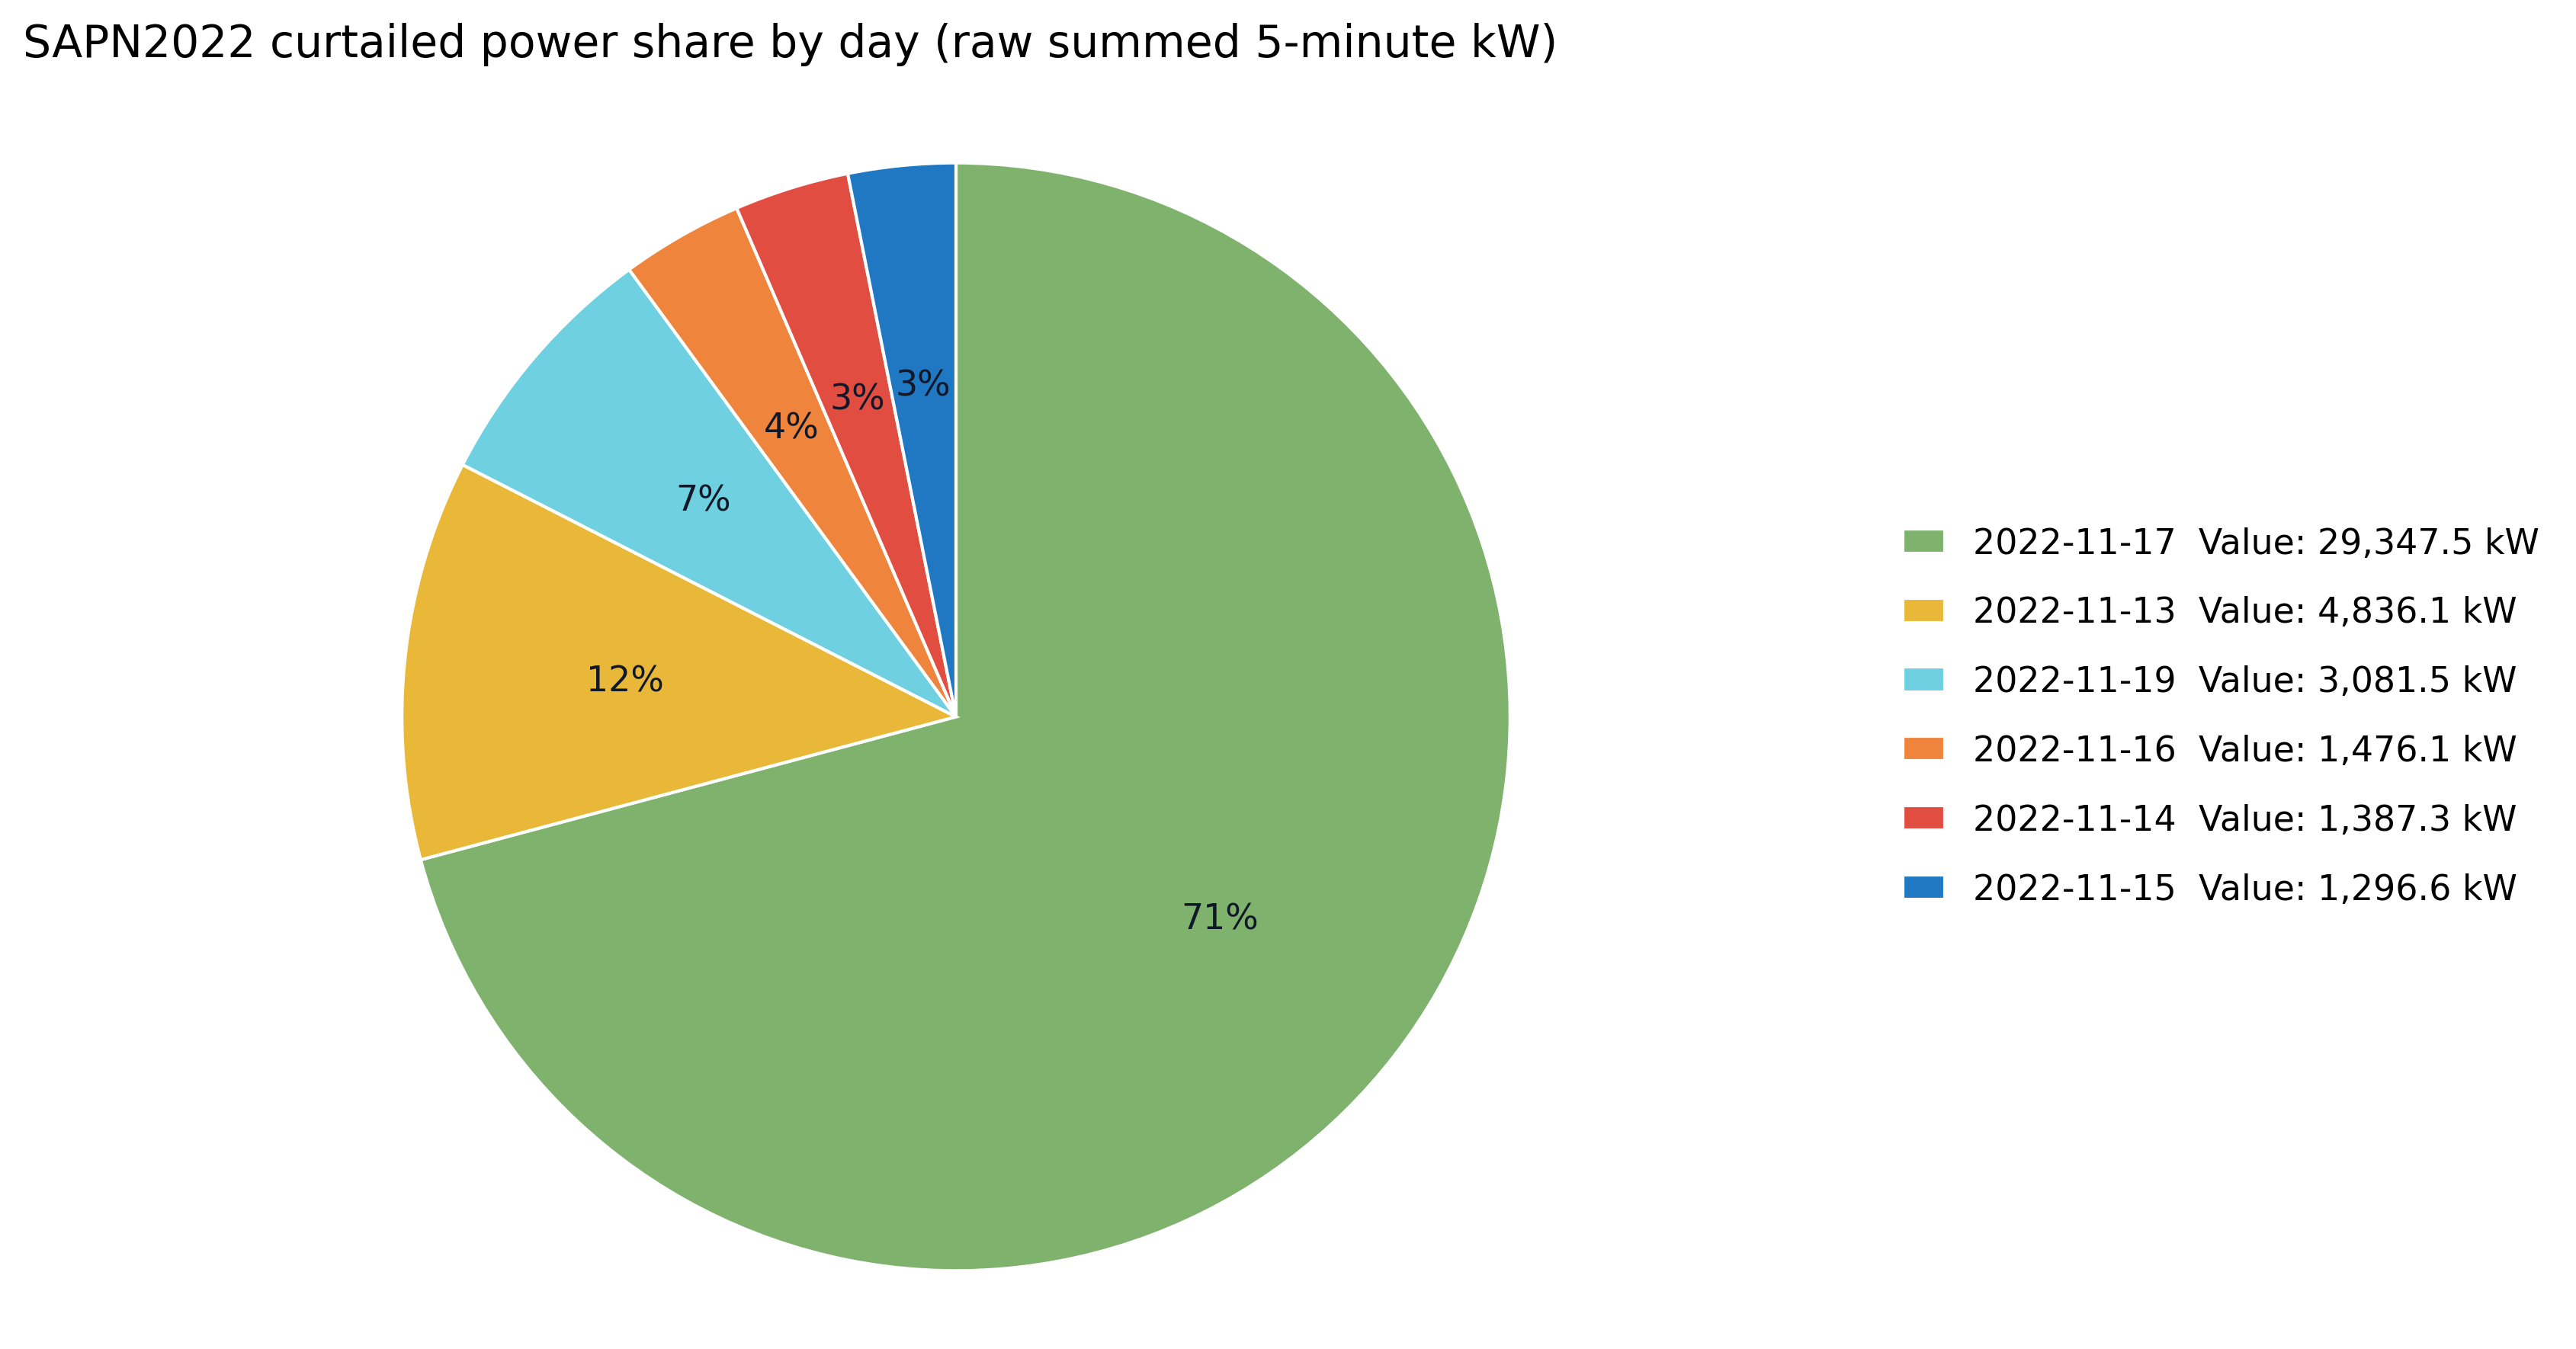

In [44]:
# Name the output file here so it is easy to change before calling the function.
# Input file used by this plot: curtailment_sapn2022_5m.parquet
raw_summary_path = DEFAULT_CURTAILMENT_SUMMARY
raw_filename = "curtailment_sapn2022_daily_pie_raw_sum.png"

fig_raw, ax_raw = plot_daily_curtailment_pie(
    summary_path=raw_summary_path,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=raw_filename,
    save=False,
)
plt.show()


## Daily curtailed energy share pie (kWh)

This function uses the same daily grouping, then converts the grouped raw total into `kWh` with `5 / 60` before plotting.

Again, keep the summary path, save folder, and filename visible at the call site.


In [45]:
def plot_daily_curtailment_pie_kwh(
    summary_path: Path,
    save_folder: Path,
    filename: str,
    save: bool = False,
):
    """Plot daily curtailed energy share using kWh converted from 5-minute values."""
    summary_path = Path(summary_path)
    save_folder = Path(save_folder)

    # Read the curtailment summary parquet.
    curtailment_df = pl.read_parquet(summary_path)

    # Stop early if the parquet has no rows.
    if curtailment_df.is_empty():
        raise ValueError(f"Curtailment summary parquet is empty: {summary_path}")

    # Group the raw curtailed power by calendar day.
    daily_totals = (
        curtailment_df
        .group_by(["year", "month", "day"])
        .agg(pl.col("curtailment_sapn2022_sum").sum().alias("daily_raw_sum"))
        .filter(pl.col("daily_raw_sum") > 0)
        .sort(["year", "month", "day"])
    )

    # Stop if no positive daily totals remain after grouping.
    if daily_totals.is_empty():
        raise ValueError(
            "Curtailment summary parquet contains no positive daily totals after aggregation: "
            f"{summary_path}"
        )

    # Use the aggregated daily total to calculate each pie slice share.
    total_raw_sum = daily_totals["daily_raw_sum"].sum()
    if total_raw_sum <= 0:
        raise ValueError(
            "Curtailment summary parquet contains a non-positive aggregated total: "
            f"{summary_path}"
        )

    # Build a readable date label, convert the grouped total to kWh, and calculate percent share.
    plot_df = daily_totals.with_columns([
        pl.date(pl.col("year"), pl.col("month"), pl.col("day"))
        .dt.strftime("%Y-%m-%d")
        .alias("date_label"),
        (pl.col("daily_raw_sum") * (5.0 / 60.0)).alias("daily_kwh"),
        (pl.col("daily_raw_sum") / pl.lit(total_raw_sum) * 100.0).alias("pct_share"),
    ]).sort("daily_kwh", descending=True)

    date_labels = plot_df["date_label"].to_list()
    values = plot_df["daily_kwh"].to_list()
    legend_labels = [
        f"{date_label}  Value: {value:,.1f} kWh"
        for date_label, value in zip(date_labels, values, strict=True)
    ]

    # Draw the pie chart.
    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    wedges, _, autotexts = ax.pie(
        values,
        colors=_slice_colors(len(values)),
        autopct=_format_pct_label,
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white", "linewidth": 1.0},
        textprops={"color": TEXT_COLOR, "fontsize": 11},
    )

    for autotext in autotexts:
        autotext.set_color(TEXT_COLOR)
        autotext.set_fontsize(11)

    ax.set_title(
        "SAPN2022 curtailed energy share by day (kWh)",
        fontsize=14,
        loc="left",
        pad=16,
    )
    ax.axis("equal")
    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        fontsize=11,
        handlelength=1.2,
        labelspacing=1.0,
        borderaxespad=0.0,
    )
    fig.subplots_adjust(left=0.06, right=0.74, top=0.90, bottom=0.08)

    # Save the figure only when requested.
    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


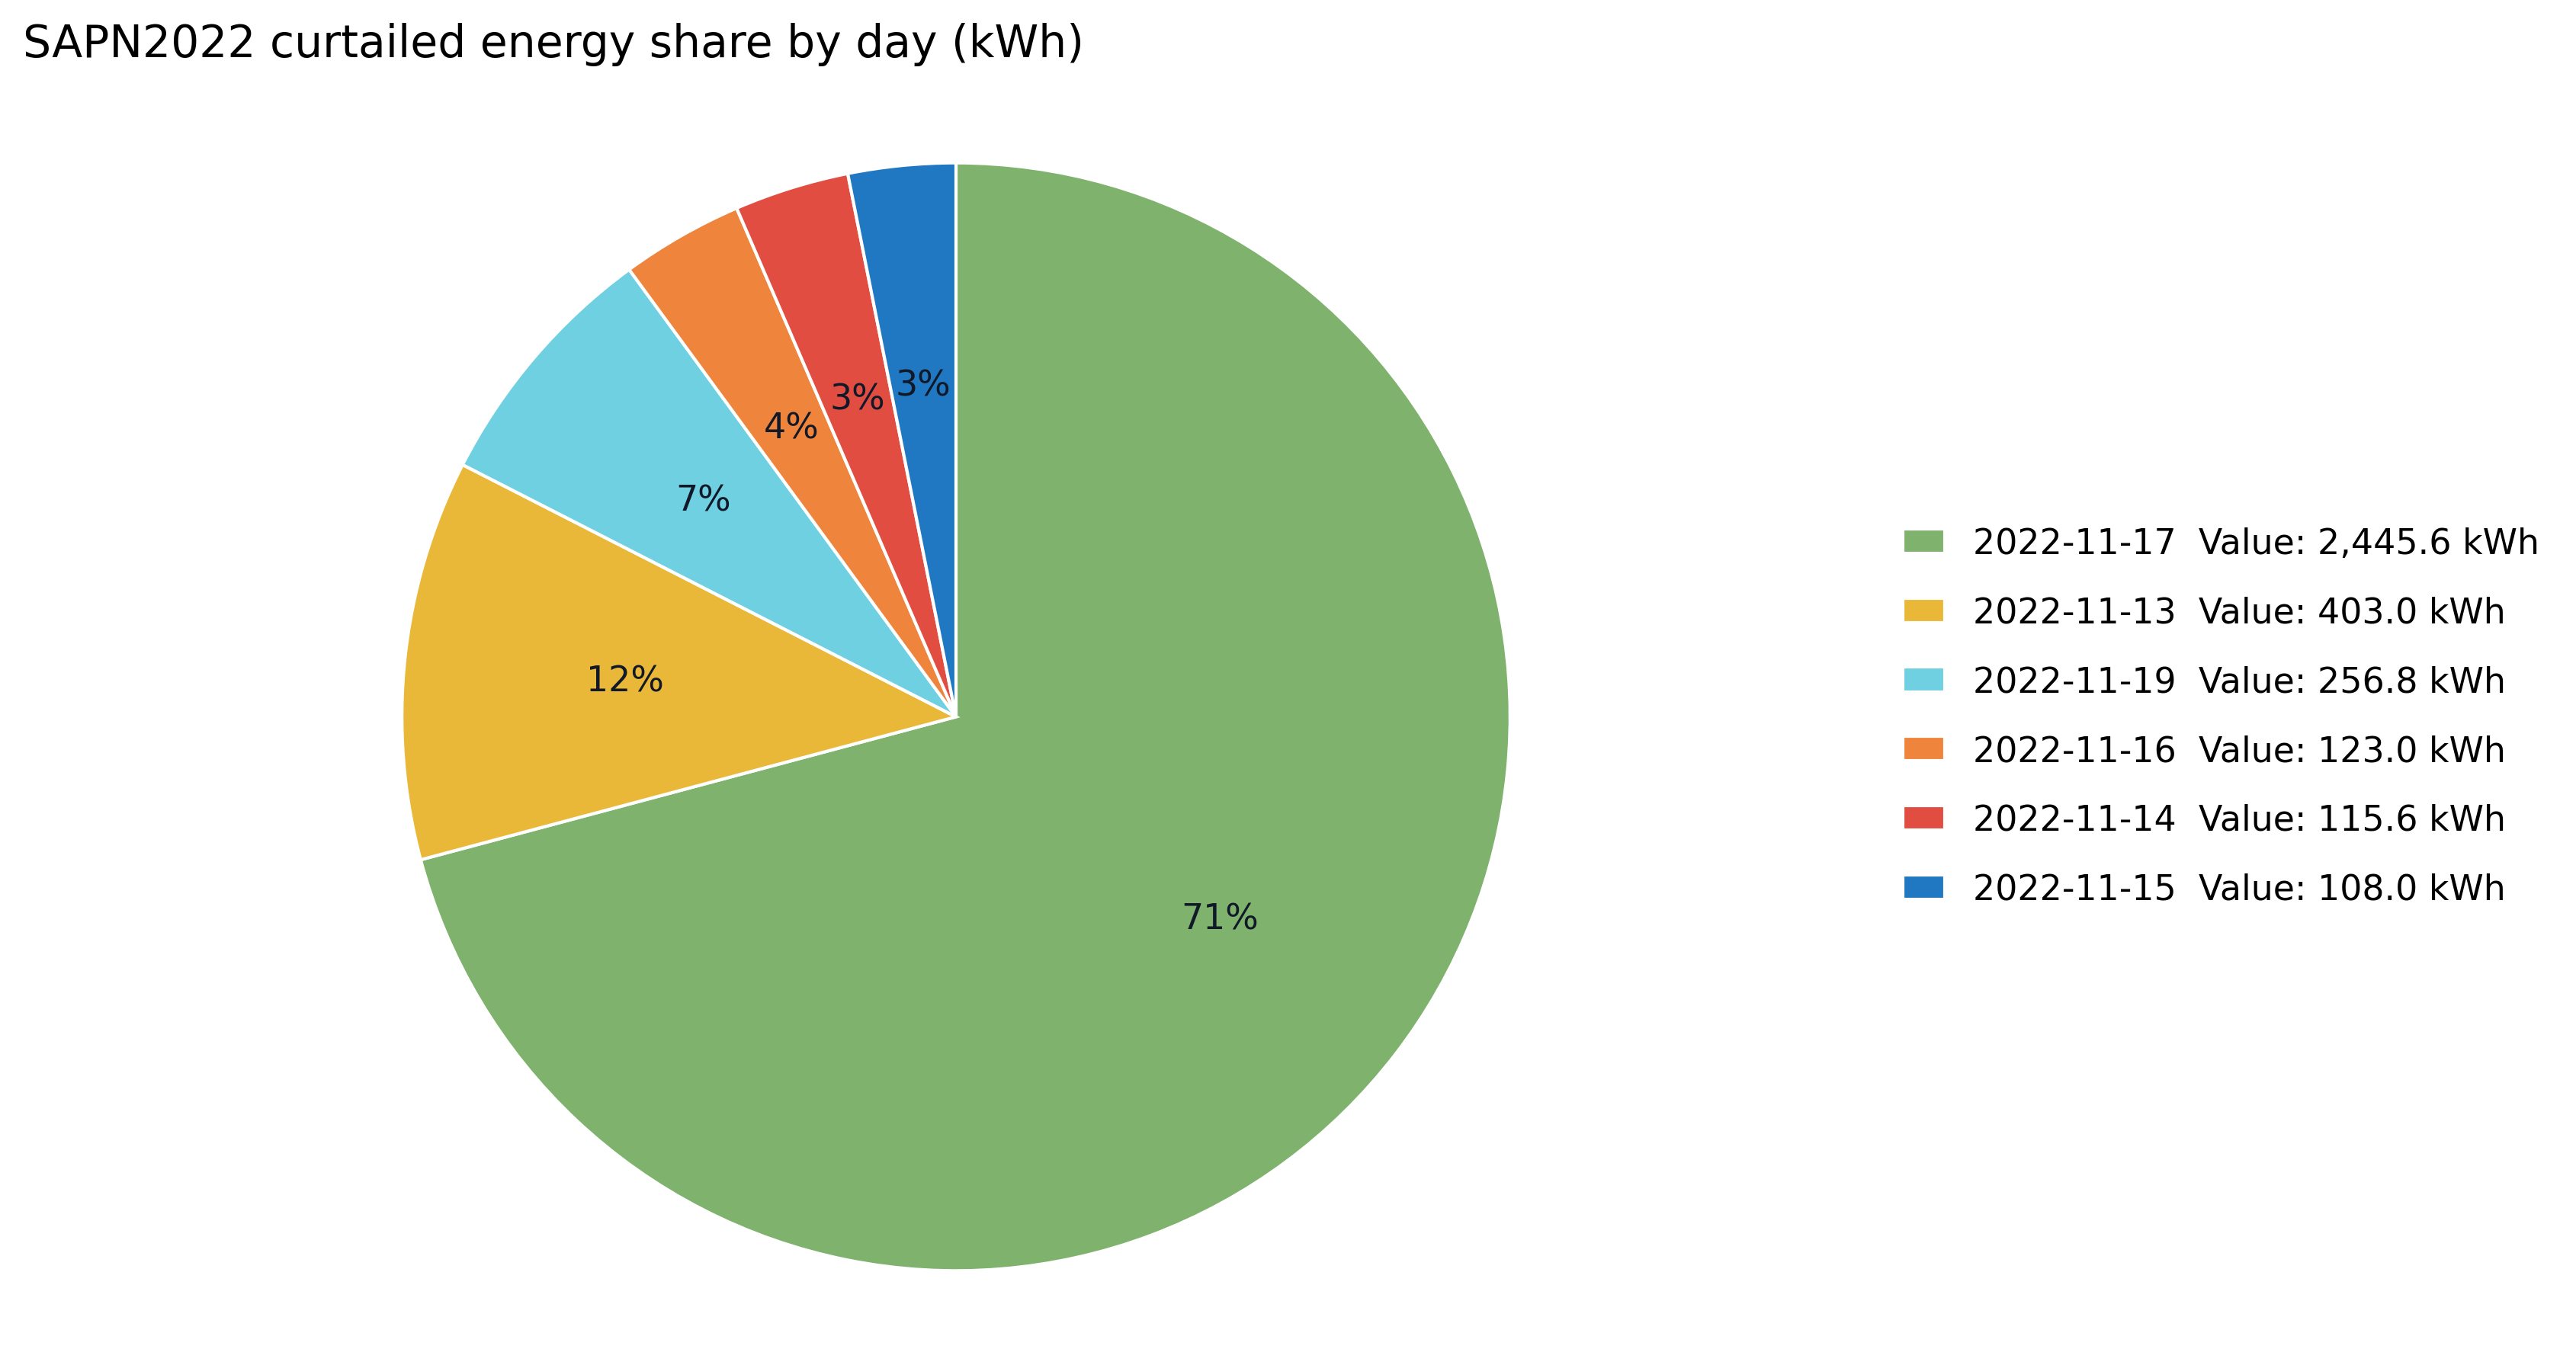

In [46]:
# Name the output file here so it is easy to change before calling the function.
# Input file used by this plot: curtailment_sapn2022_5m.parquet
kwh_summary_path = DEFAULT_CURTAILMENT_SUMMARY
kwh_filename = "curtailment_sapn2022_daily_pie_kwh.png"

fig_kwh, ax_kwh = plot_daily_curtailment_pie_kwh(
    summary_path=kwh_summary_path,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=kwh_filename,
    save=False,
)
plt.show()


## Per-site estimated available energy curtailed percentage ranked dot plot

This section works from the raw eligible 5-minute buckets rather than the daily summary parquet so it can
calculate a site-level percentage of estimated available energy curtailed during `LOS/OV1` responsibility windows.

Each retained site is shown as one point after filtering to sites with at least a chosen number of eligible buckets.


In [47]:
DEFAULT_ALL_UNCURTAILED_5M = (
    PROJECT_ROOT / "outputs" / "prediction" / "all_uncurtailedPV_5m.parquet"
)


def _default_eligible_buckets_path() -> Path:
    """Load the external eligible-bucket path only when this plot is used."""
    if str(SCRIPTS_DIR) not in sys.path:
        sys.path.insert(0, str(SCRIPTS_DIR))

    from run_sapn2022_metrics_5m import DEFAULT_ELIGIBLE_BUCKETS5M

    return Path(DEFAULT_ELIGIBLE_BUCKETS5M)


def _site_curtailment_pct_ranked_data(
    eligible_buckets_path: Path,
    all_uncurtailed_path: Path,
    min_eligible_buckets: int = 10,
) -> pl.DataFrame:
    """Return one ranked `% curtailed` value per site that passes the 5-minute bucket threshold."""
    if min_eligible_buckets < 1:
        raise ValueError("min_eligible_buckets must be at least 1")

    eligible_buckets_path = Path(eligible_buckets_path)
    all_uncurtailed_path = Path(all_uncurtailed_path)

    if str(SCRIPTS_DIR) not in sys.path:
        sys.path.insert(0, str(SCRIPTS_DIR))

    from run_sapn2022_metrics_5m import bucket_rows, uncurtailed_rows

    eligible_rows = (
        bucket_rows(pl.scan_csv(eligible_buckets_path))
        .filter(pl.col("los_or_ov1_flag") == 1)
        .select(["site_id", "local_tstamp"])
    )

    uncurtailed = (
        uncurtailed_rows(pl.scan_parquet(all_uncurtailed_path))
        .select(["site_id", "local_tstamp", "P_kw", "uncurtailed_P"])
    )

    plot_df = (
        eligible_rows
        .join(uncurtailed, on=["site_id", "local_tstamp"], how="inner")
        .filter(
            pl.col("P_kw").is_not_null()
            & pl.col("uncurtailed_P").is_not_null()
            & (pl.col("uncurtailed_P") > 0)
        )
        .with_columns(
            pl.max_horizontal(pl.col("uncurtailed_P") - pl.col("P_kw"), pl.lit(0.0))
            .alias("curtailed_P")
        )
        .group_by("site_id")
        .agg([
            pl.len().alias("eligible_count"),
            pl.col("curtailed_P").sum().alias("sum_curtail"),
            pl.col("uncurtailed_P").sum().alias("sum_uncurtailed"),
        ])
        .filter(
            (pl.col("eligible_count") >= min_eligible_buckets)
            & (pl.col("sum_uncurtailed") > 0)
        )
        .with_columns(
            (pl.col("sum_curtail") / pl.col("sum_uncurtailed") * 100.0)
            .alias("site_pct_curtailed")
        )
        .select(["site_id", "eligible_count", "sum_curtail", "sum_uncurtailed", "site_pct_curtailed"])
        .sort(["site_pct_curtailed", "site_id"], descending=[True, False])
        .collect()
    )

    if plot_df.is_empty():
        raise ValueError(
            "No sites remain after joining eligible rows and applying the minimum eligible bucket filter."
        )

    return plot_df.with_columns(pl.Series("site_rank", range(1, plot_df.height + 1)))


def plot_site_curtailment_pct_ranked(
    eligible_buckets_path: Path,
    all_uncurtailed_path: Path,
    save_folder: Path,
    filename: str,
    min_eligible_buckets: int = 10,
    save: bool = False,
):
    """Plot one descending ranked `% curtailed` point per retained site."""
    save_folder = Path(save_folder)
    plot_df = _site_curtailment_pct_ranked_data(
        eligible_buckets_path=eligible_buckets_path,
        all_uncurtailed_path=all_uncurtailed_path,
        min_eligible_buckets=min_eligible_buckets,
    )

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.scatter(
        plot_df["site_rank"].to_list(),
        plot_df["site_pct_curtailed"].to_list(),
        s=26,
        color=GRAFANA_CLASSIC_COLORS[-1],
        edgecolors="white",
        linewidths=0.5,
        alpha=0.9,
    )

    ax.set_title(
        "SAPN2022 per-site estimated available energy curtailed during eligible LOS/OV1 buckets",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} sites retained with at least {min_eligible_buckets} eligible 5-minute buckets "
            "(`los_or_ov1_flag == 1`)"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel("Site rank", fontsize=11)
    ax.set_ylabel(
        "Estimated available energy curtailed (%)",
        fontsize=11,
    )
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, plot_df.height + 0.5)

    tick_step = max(1, plot_df.height // 10)
    rank_ticks = sorted(set(range(1, plot_df.height + 1, tick_step)) | {plot_df.height})
    ax.set_xticks(rank_ticks)

    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


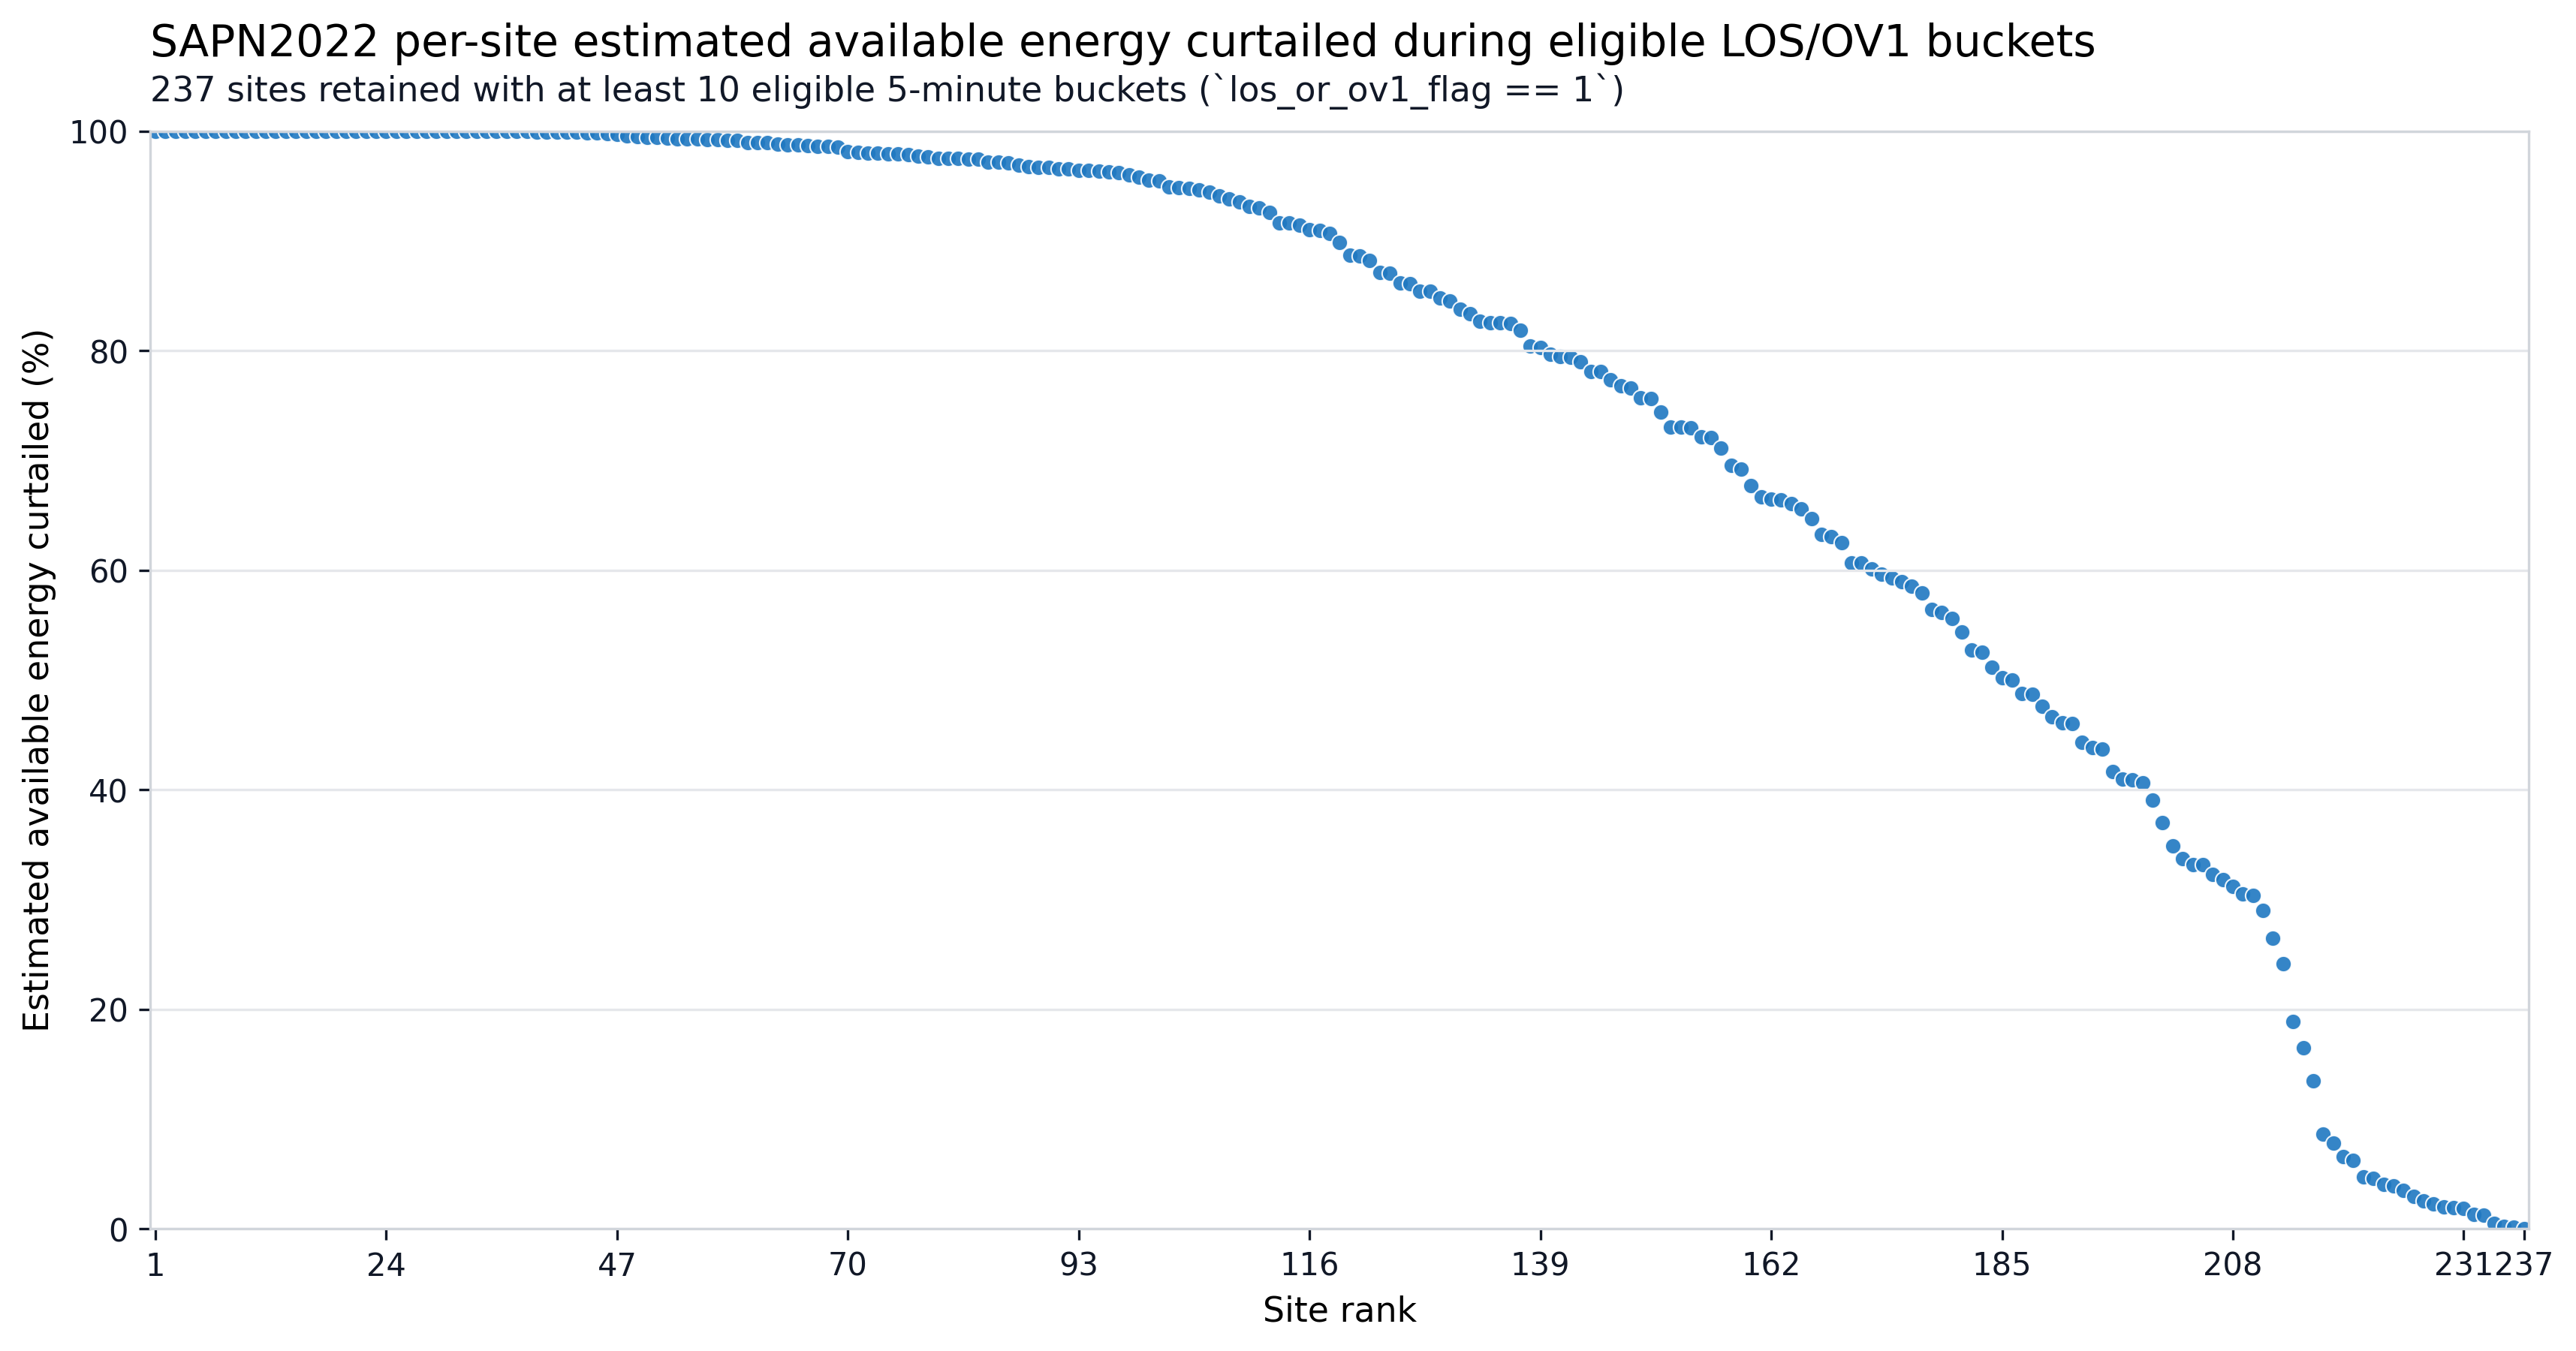

In [48]:
# Name the output file here so it is easy to change before calling the function.
# Input files used by this plot:
# - ranked_eligible_buckets_path: tier_based_5min_buckets.csv
# - ranked_uncurtailed_path: all_uncurtailedPV_5m.parquet

ranked_eligible_buckets_path = _default_eligible_buckets_path()
ranked_uncurtailed_path = DEFAULT_ALL_UNCURTAILED_5M
ranked_filename = "curtailment_sapn2022_site_pct_ranked.png"

fig_ranked, ax_ranked = plot_site_curtailment_pct_ranked(
    eligible_buckets_path=ranked_eligible_buckets_path,
    all_uncurtailed_path=ranked_uncurtailed_path,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=ranked_filename,
    min_eligible_buckets=10,
    save=False,
)
plt.show()


## Per-site estimated available energy curtailed percentage histogram

This section reuses the same filtered site-level estimated available energy curtailed percentages as the ranked dot plot. 

It groups them into percentage bins so the x-axis is estimated available energy curtailed percentage and the y-axis is number of sites.

The displayed percentage axis runs from high to low so the highest curtailed percentages stay on the left.


In [49]:
def plot_site_curtailment_pct_histogram(
    eligible_buckets_path: Path,
    all_uncurtailed_path: Path,
    save_folder: Path,
    filename: str,
    min_eligible_buckets: int = 10,
    bins: int | list[float] = 20,
    save: bool = False,
):
    """Plot a histogram of retained site `% curtailed` values."""
    save_folder = Path(save_folder)
    plot_df = _site_curtailment_pct_ranked_data(
        eligible_buckets_path=eligible_buckets_path,
        all_uncurtailed_path=all_uncurtailed_path,
        min_eligible_buckets=min_eligible_buckets,
    )

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(
        plot_df["site_pct_curtailed"].to_list(),
        bins=bins,
        color=GRAFANA_CLASSIC_COLORS[0],
        edgecolor="white",
        linewidth=1.0,
        alpha=0.95,
    )

    ax.set_title(
        "SAPN2022 distribution of per-site estimated available energy curtailed during eligible LOS/OV1 buckets",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} sites retained with at least {min_eligible_buckets} eligible 5-minute buckets "
            "(`los_or_ov1_flag == 1`)"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel(
        "Estimated available energy curtailed during eligible LOS/OV1 5-minute buckets (%)",
        fontsize=11,
    )
    ax.set_ylabel("Number of sites", fontsize=11)
    ax.set_xlim(100, 0)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


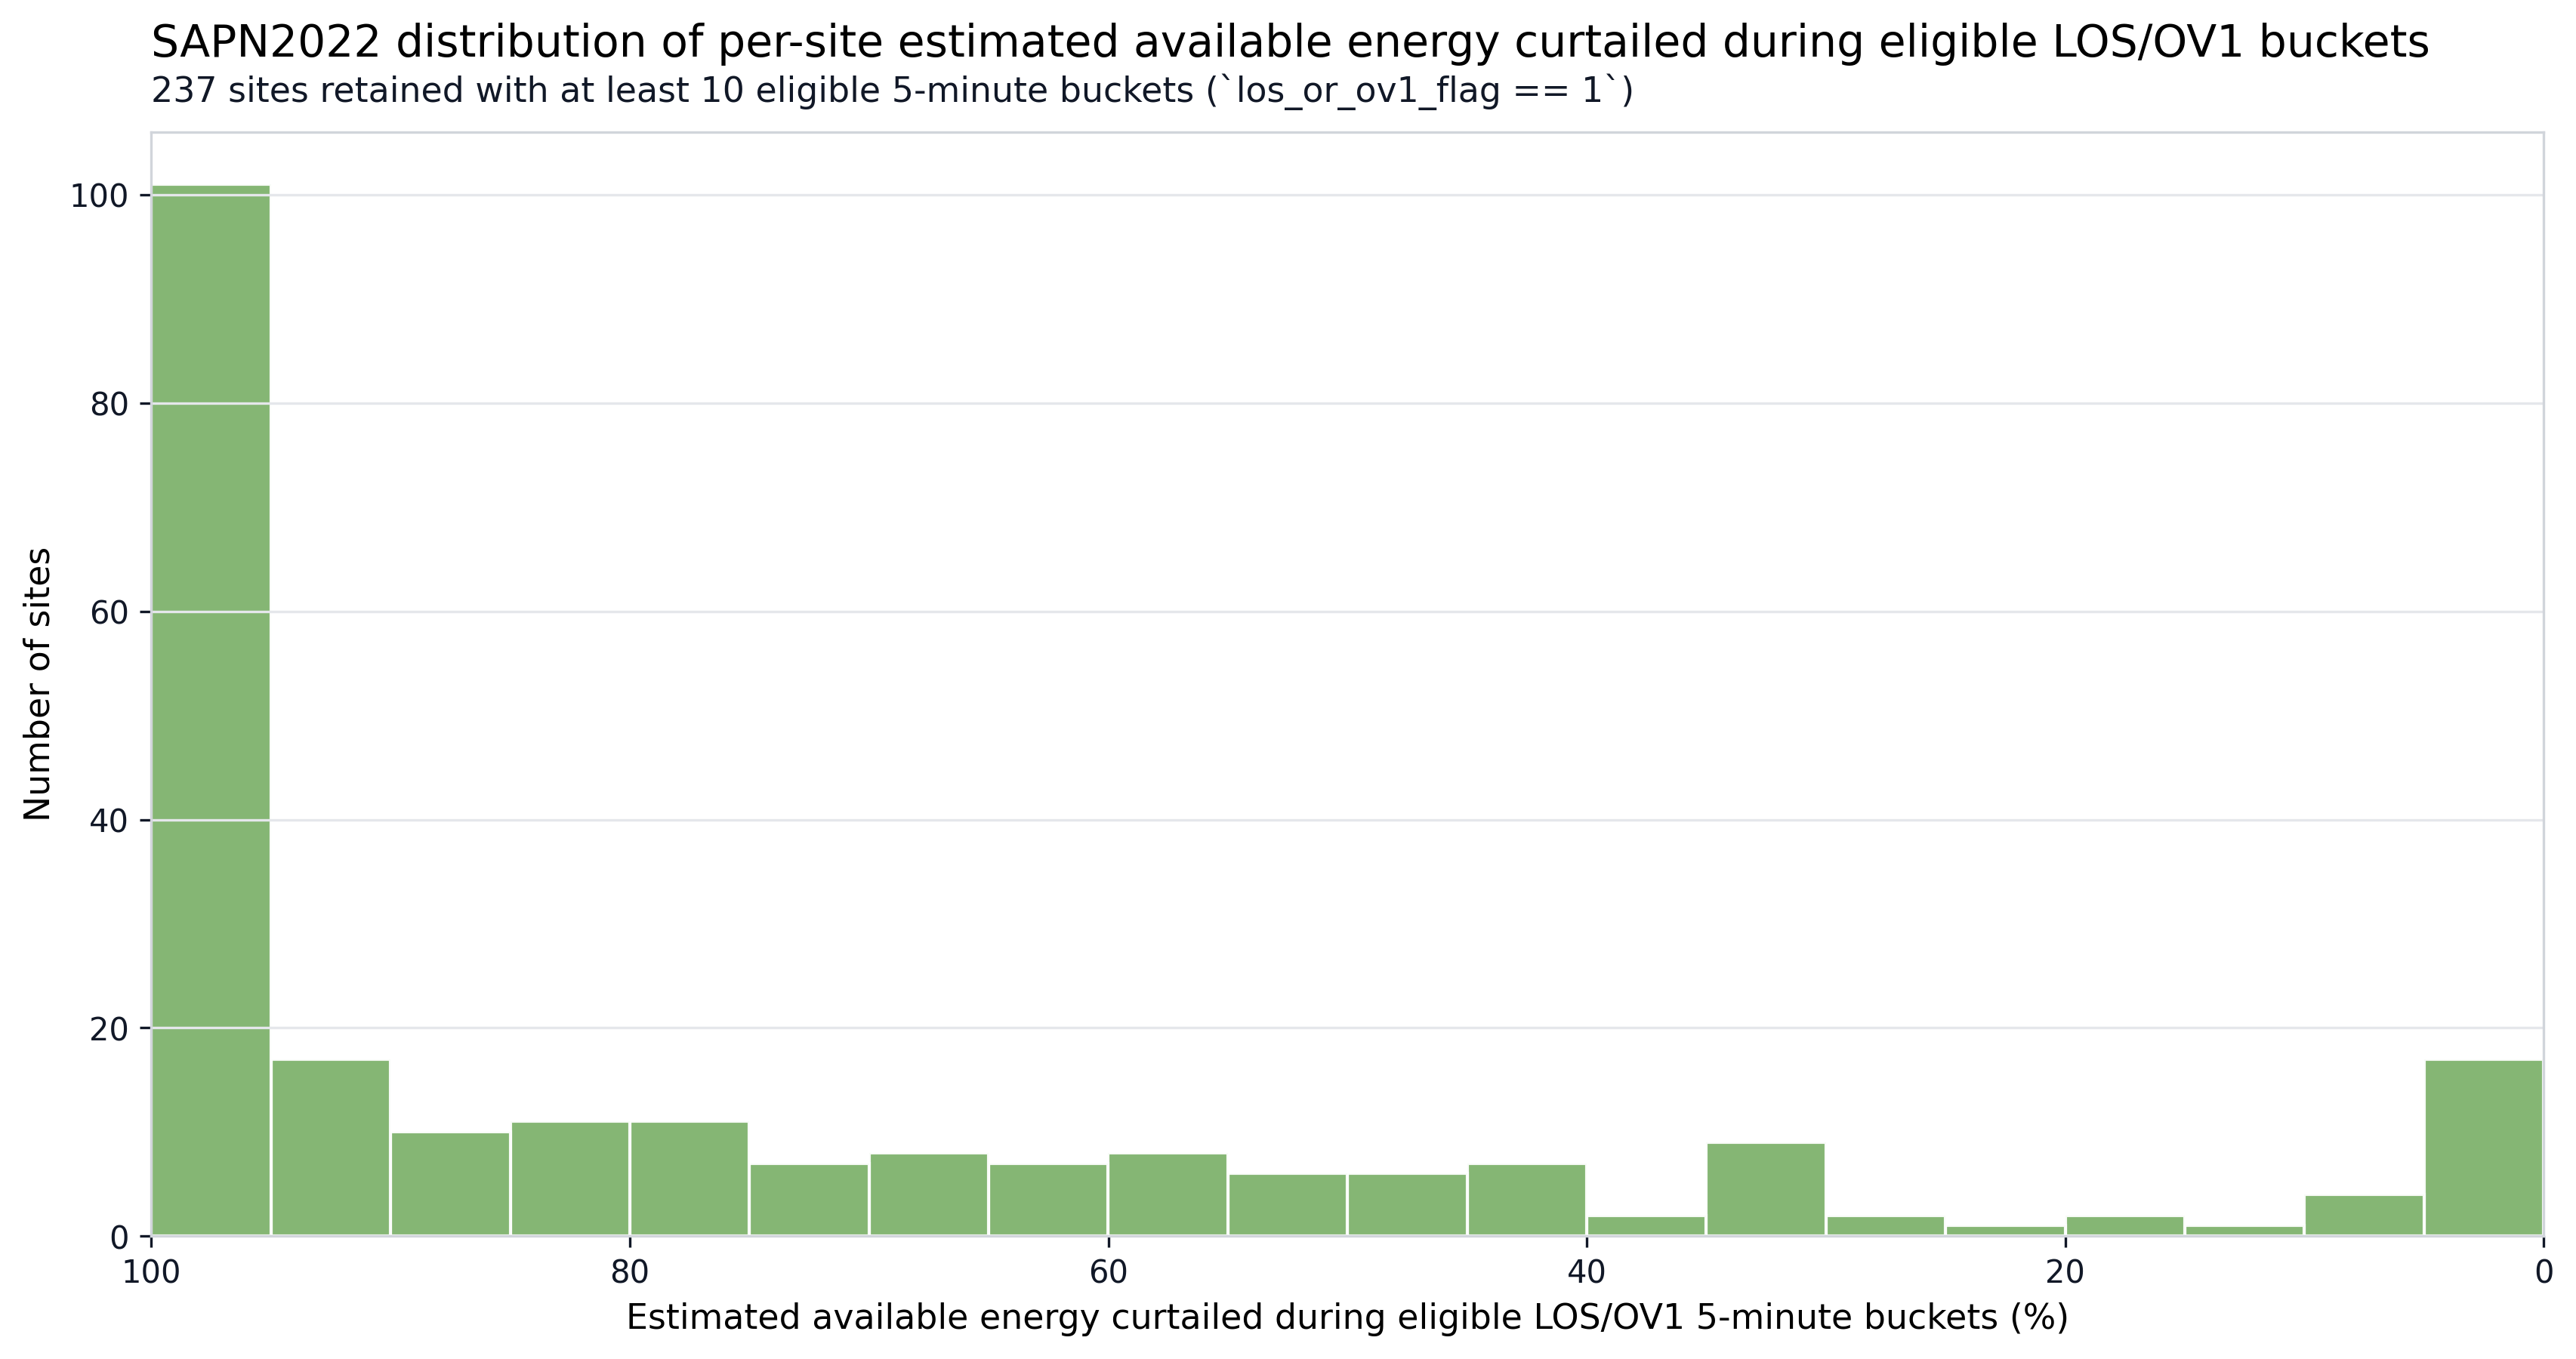

In [50]:
# Name the output file here so it is easy to change before calling the function.
# Input files used by this plot:
# - hist_eligible_buckets_path: tier_based_5min_buckets.csv
# - hist_uncurtailed_path: all_uncurtailedPV_5m.parquet

hist_eligible_buckets_path = _default_eligible_buckets_path()
hist_uncurtailed_path = DEFAULT_ALL_UNCURTAILED_5M
hist_filename = "curtailment_sapn2022_site_pct_histogram.png"

fig_hist, ax_hist = plot_site_curtailment_pct_histogram(
    eligible_buckets_path=hist_eligible_buckets_path,
    all_uncurtailed_path=hist_uncurtailed_path,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=hist_filename,
    min_eligible_buckets=10,
    bins=20,
    save=False,
)
plt.show()


## Per-site curtailed energy normalised by:
* PLOT 1A and 1B: Normalised by AC capacity and eligible days (specific to the site)
* PLOT 2A and 2B: Normalised by AC capacity and eligible 5m bins (specific to the site)

This section reuses the daily curtailment summary so the curtailed-energy numerator and support counts come from the same scored site-day rows. 

Here, `total_count` means matched eligible 5-minute bins, including bins with zero curtailment (curtailment + non-curtailment bins). 

While `curtailment_sapn2022_count` counts only positive-curtailment bins (where curtailment happened).

Each retained site is shown as one point after filtering to sites with at least a chosen number of matched eligible bins.


### This cell is for shared functions for the above four plots


In [51]:
def _site_curtailment_kwh_per_kw_base_data(
    curtailment_summary_df: pl.DataFrame,
    structured_data_df: pl.DataFrame,
    min_matched_eligible_bins: int = 10,
) -> pl.DataFrame:
    """Return shared site-level curtailment inputs before metric-specific normalisation."""
    if min_matched_eligible_bins < 1:
        raise ValueError("min_matched_eligible_bins must be at least 1")

    if curtailment_summary_df.is_empty():
        raise ValueError("Curtailment summary parquet is empty.")

    if structured_data_df.is_empty():
        raise ValueError("Structured data parquet is empty.")

    # `total_count` is the matched eligible LOS/OV1 5-minute bin count,
    # including bins with zero curtailment. `curtailment_sapn2022_count`
    # counts only positive-curtailment bins. Use `total_count` for support
    # filtering so the retained cohort stays aligned with the energy numerator.
    site_summary = (
        curtailment_summary_df
        .select([
            pl.col("site_id").cast(pl.Int64),
            pl.col("curtailment_sapn2022_sum").cast(pl.Float64),
            pl.col("curtailment_sapn2022_count").cast(pl.Int64),
            pl.col("total_count").cast(pl.Int64),
        ])
        .group_by("site_id")
        .agg([
            pl.len().cast(pl.Int64).alias("site_day_count"),
            pl.col("total_count").sum().alias("matched_eligible_bin_count"),
            pl.col("curtailment_sapn2022_count").sum().alias("positive_curtailment_bin_count"),
            pl.col("curtailment_sapn2022_sum").sum().alias("total_curtailment_raw_sum"),
        ])
    )

    capacity_by_site = (
        structured_data_df
        .select([
            pl.col("site_id").cast(pl.Int64),
            pl.col("ac_capacity_kw").cast(pl.Float64, strict=False),
        ])
        .filter(pl.col("ac_capacity_kw").is_not_null())
        .group_by("site_id")
        .agg([
            pl.col("ac_capacity_kw").n_unique().alias("capacity_value_count"),
            pl.col("ac_capacity_kw").first().alias("ac_capacity_kw"),
        ])
    )

    conflicting_capacity = capacity_by_site.filter(pl.col("capacity_value_count") > 1)
    if not conflicting_capacity.is_empty():
        conflicting_sites = conflicting_capacity["site_id"].to_list()[:10]
        raise ValueError(
            "Structured data parquet contains multiple ac_capacity_kw values for site_ids: "
            f"{conflicting_sites}"
        )

    base_df = site_summary.join(
        capacity_by_site.select(["site_id", "ac_capacity_kw"]),
        on="site_id",
        how="left",
    )

    missing_capacity = base_df.filter(pl.col("ac_capacity_kw").is_null())
    if not missing_capacity.is_empty():
        missing_sites = missing_capacity["site_id"].to_list()[:10]
        raise ValueError(
            "No ac_capacity_kw was found in structured_data_5m.parquet for site_ids: "
            f"{missing_sites}"
        )

    base_df = (
        base_df
        .filter(
            (pl.col("ac_capacity_kw") > 0)
            & (pl.col("matched_eligible_bin_count") >= min_matched_eligible_bins)
        )
        .with_columns(
            (pl.col("total_curtailment_raw_sum") * (5.0 / 60.0)).alias("total_curtailment_kwh")
        )
        .select([
            "site_id",
            "site_day_count",
            "matched_eligible_bin_count",
            "positive_curtailment_bin_count",
            "ac_capacity_kw",
            "total_curtailment_raw_sum",
            "total_curtailment_kwh",
        ])
        .sort("site_id")
    )

    if base_df.is_empty():
        raise ValueError(
            "No sites remain after joining capacity and applying the minimum matched eligible bin filter."
        )

    return base_df


def _site_curtailment_kwh_per_kw_day_plot_data(base_df: pl.DataFrame) -> pl.DataFrame:
    """Add the per-day normalisation and rank sites descending."""
    return (
        base_df
        .with_columns(
            (
                pl.col("total_curtailment_kwh") # total curtailment for a site
                / pl.col("ac_capacity_kw") # normalise with the system capacity
                / pl.col("site_day_count") # normalise with number of days it was meant to be curtailing (days when it exceeded LOS/OV threshold)
            ).alias("site_kwh_per_kw_per_day")
        )
        .sort(["site_kwh_per_kw_per_day", "site_id"], descending=[True, False])
        .with_row_count("site_rank", offset=1)
    )


def _site_curtailment_kwh_per_kw_time_bin_plot_data(base_df: pl.DataFrame) -> pl.DataFrame:
    """Add the per-time-bin normalisation and rank sites descending."""
    return (
        base_df
        .with_columns(
            (
                pl.col("total_curtailment_kwh") # total curtailment for a site
                / pl.col("ac_capacity_kw") # normalise with the system capacity
                / pl.col("matched_eligible_bin_count") # normalise with number of bins when threshold exceeds for LOS/OV
            ).alias("site_kwh_per_kw_per_time_bin")
        )
        .sort(["site_kwh_per_kw_per_time_bin", "site_id"], descending=[True, False])
        .with_row_count("site_rank", offset=1)
    )



### Plots for energy normlaised by AC capacity and number of eligible days


In [52]:

def plot_site_curtailment_kwh_per_kw_day_ranked(
    plot_df: pl.DataFrame,
    save_folder: Path,
    filename: str,
    min_matched_eligible_bins: int = 10,
    save: bool = False,
):
    """Plot one descending ranked `kWh/kW/day` point per retained site."""
    save_folder = Path(save_folder)

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.scatter(
        plot_df["site_rank"].to_list(),
        plot_df["site_kwh_per_kw_per_day"].to_list(),
        s=26,
        color=GRAFANA_CLASSIC_COLORS[2],
        edgecolors="white",
        linewidths=0.5,
        alpha=0.9,
    )

    ax.set_title(
        "SAPN2022 per-site curtailed energy normalised by AC capacity and eligible days",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} sites retained with at least {min_matched_eligible_bins} matched eligible 5-minute bins "
            "(`total_count`)"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel("Site rank", fontsize=11)
    ax.set_ylabel("Normalied total energy curtailed (kWh/kW/day)", fontsize=11)
    ax.set_xlim(0.5, plot_df.height + 0.5)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


def plot_site_curtailment_kwh_per_kw_day_histogram(
    plot_df: pl.DataFrame,
    save_folder: Path,
    filename: str,
    min_matched_eligible_bins: int = 10,
    bins: int | list[float] = 20,
    save: bool = False,
):
    """Plot a histogram of retained site `kWh/kW/day` values."""
    save_folder = Path(save_folder)

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(
        plot_df["site_kwh_per_kw_per_day"].to_list(),
        bins=bins,
        color=GRAFANA_CLASSIC_COLORS[3],
        edgecolor="white",
        linewidth=1.0,
        alpha=0.95,
    )

    ax.set_title(
        "SAPN2022 distribution of per-site curtailed energy normalised by AC capacity and eligible site-days",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} sites retained with at least {min_matched_eligible_bins} matched eligible 5-minute bins "
            "(`total_count`)"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel("Average curtailed energy per kW AC capacity per matched eligible site-day (kWh/kW/day)", fontsize=11)
    ax.set_ylabel("Number of sites", fontsize=11)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax

In [53]:
# call the required fucnctions before plotting
# change these inputs here before generating the per-site curtailed energy normlalised plots.
# describe these two call function for the four plots
kwh_per_kw_day_summary_path = DEFAULT_CURTAILMENT_SUMMARY
kwh_per_kw_day_structured_path = DEFAULT_STRUCTURED_DATA_5M
min_matched_eligible_bins = 10

curtailment_summary_df = pl.read_parquet(kwh_per_kw_day_summary_path)
structured_data_df = pl.read_parquet(kwh_per_kw_day_structured_path)

site_curtailment_kwh_per_kw_base_df = _site_curtailment_kwh_per_kw_base_data(
    curtailment_summary_df=curtailment_summary_df,
    structured_data_df=structured_data_df,
    min_matched_eligible_bins=min_matched_eligible_bins,
)

site_curtailment_kwh_per_kw_day_df = _site_curtailment_kwh_per_kw_day_plot_data(
    site_curtailment_kwh_per_kw_base_df
)


/var/folders/2m/0bhk_4qs61n2y1rtr16y0nxc0000gp/T/ipykernel_47548/1528702760.py:114: DeprecationWarning: `DataFrame.with_row_count` is deprecated; use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count("site_rank", offset=1)


### PLOT 1A - total energy curtailed normalised by system capacity and day (kWh/kW/day)

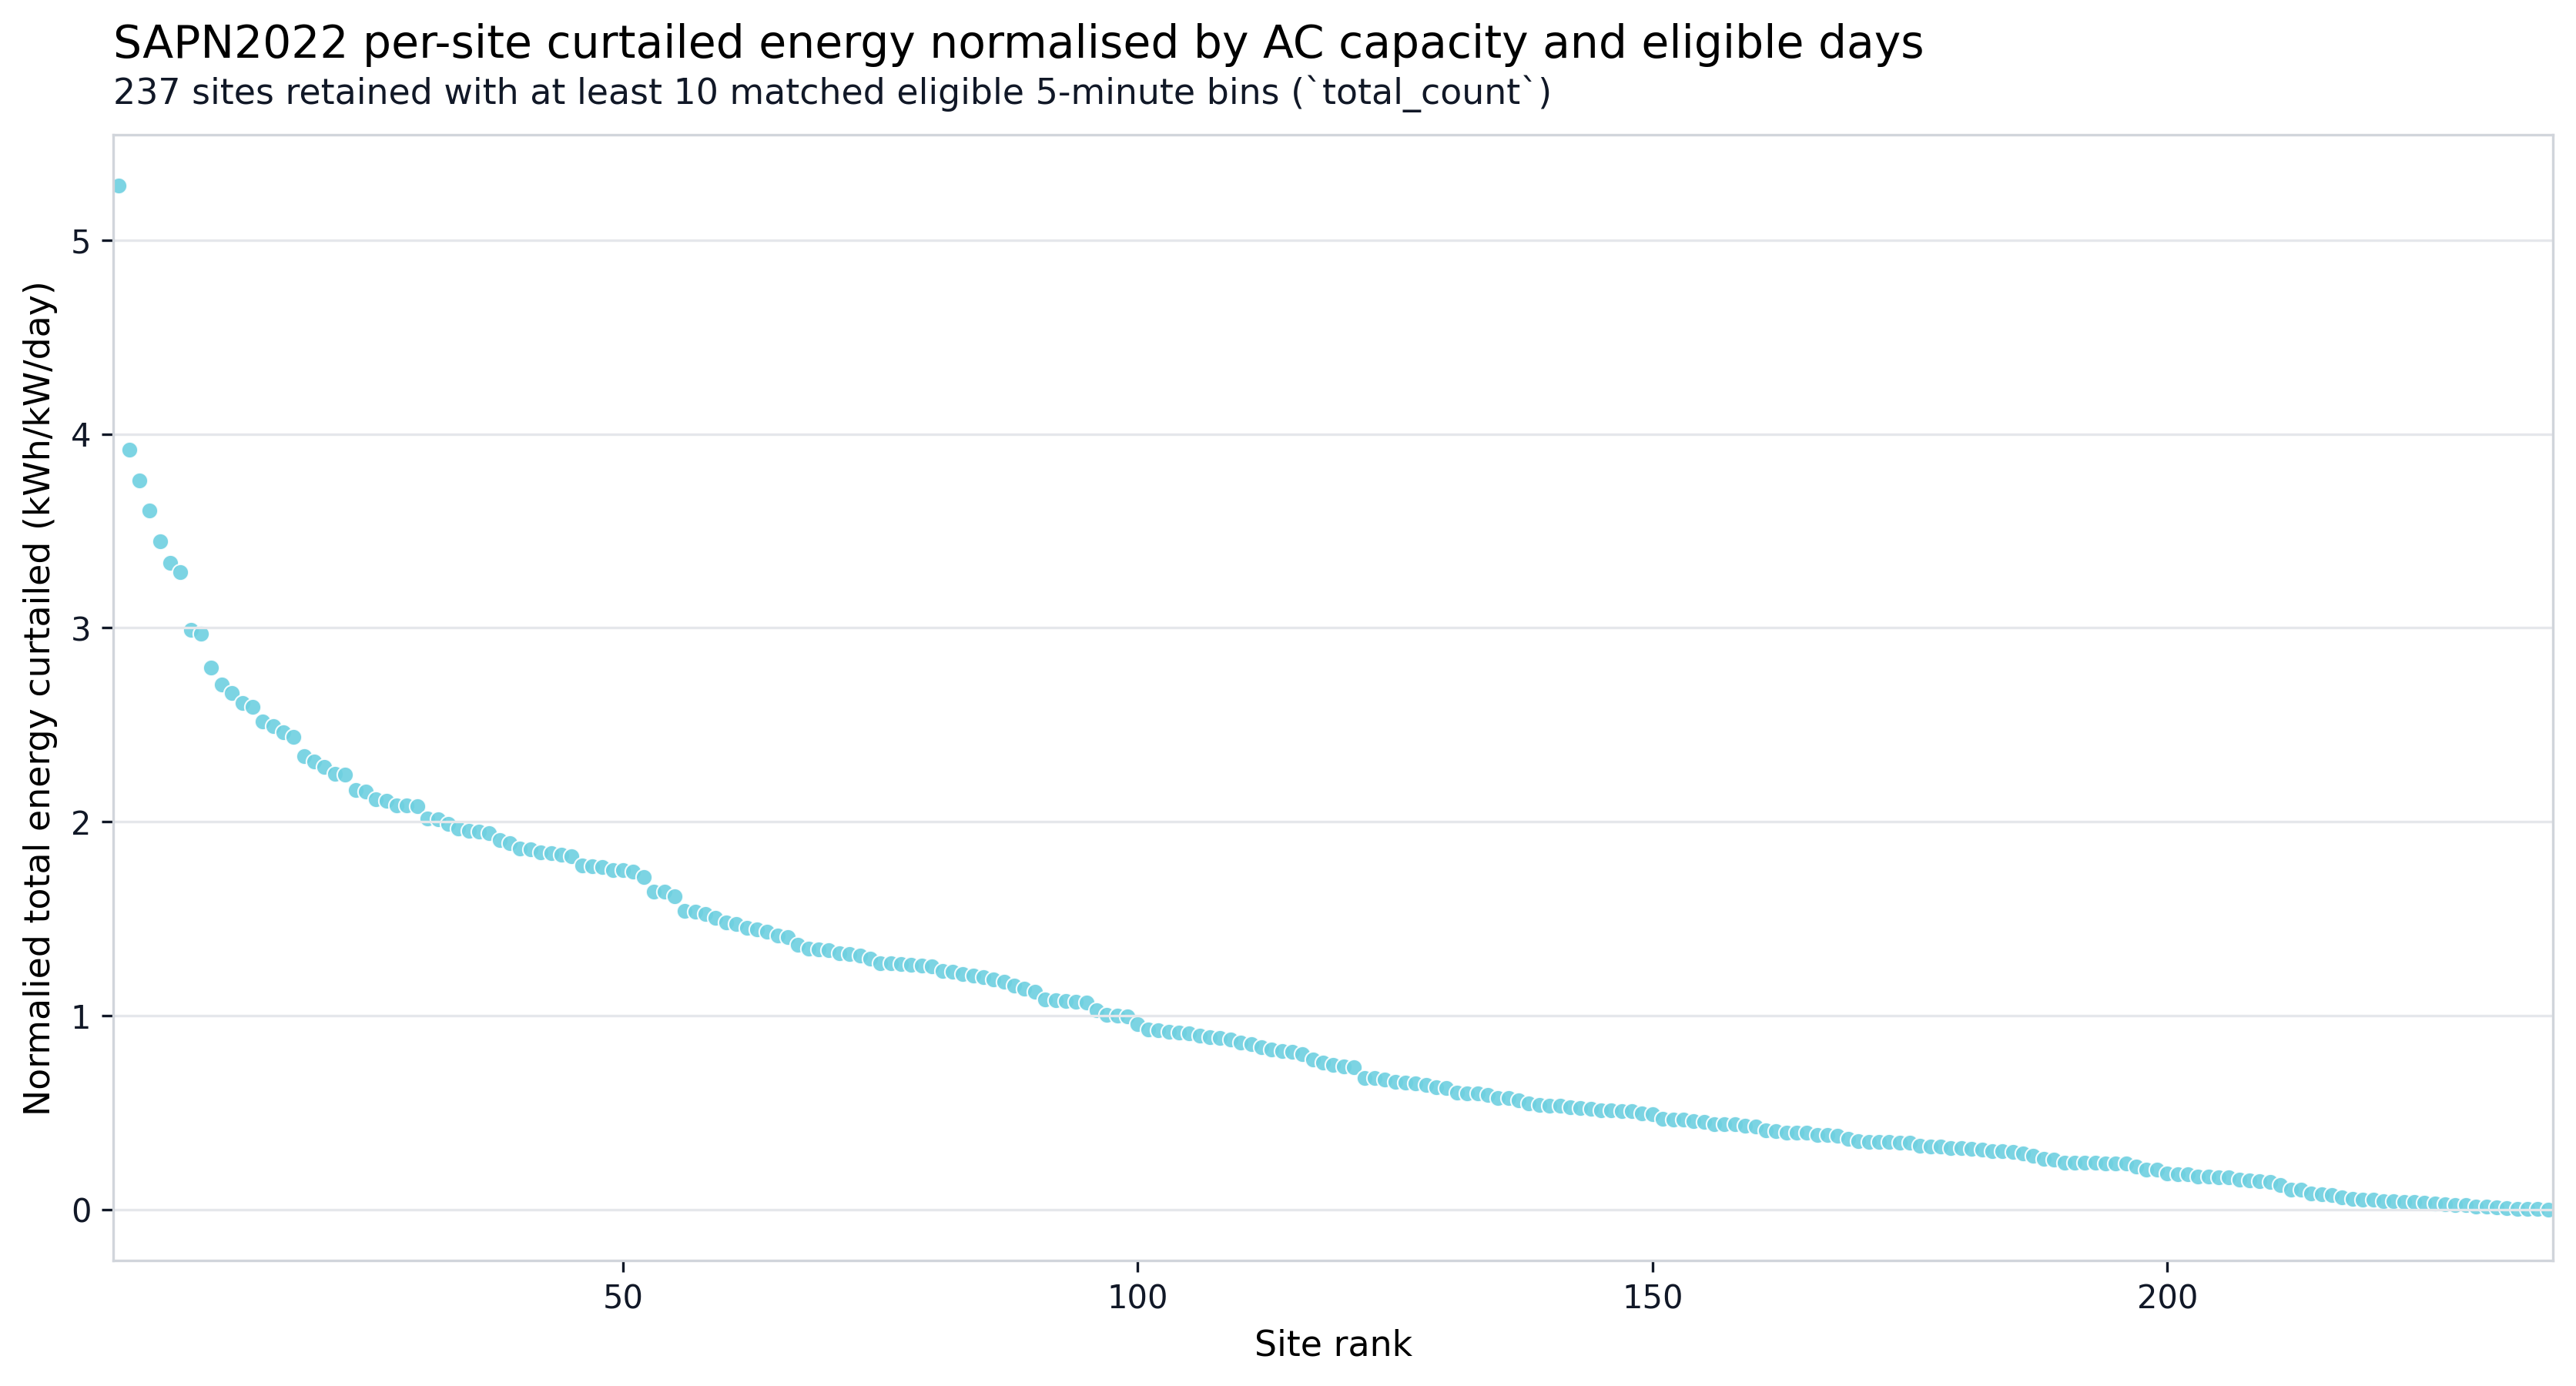

In [54]:

# Name the output file here so it is easy to change before calling the function.
# Input files used by this plot:
# - kwh_per_kw_day_summary_path: curtailment_sapn2022_5m.parquet
# - kwh_per_kw_day_structured_path: structured_data_5m.parquet
kwh_per_kw_day_ranked_filename = "curtailment_sapn2022_site_kwh_per_kw_day_ranked.png"
min_matched_eligible_bins      = 10
 
fig_kwh_per_kw_day_ranked, ax_kwh_per_kw_day_ranked = plot_site_curtailment_kwh_per_kw_day_ranked(
    plot_df=site_curtailment_kwh_per_kw_day_df,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=kwh_per_kw_day_ranked_filename,
    min_matched_eligible_bins=min_matched_eligible_bins,
    save=False,
)
plt.show()


### PLOT 1B - total energy curtailed normalised by system capacity and day (kWh/kW/day) Histogram

This section reuses the same retained site-level `kWh/kW/day` values as the ranked dot plot.

It groups them into bins so the x-axis is average curtailed energy per kW AC capacity per matched eligible site-day and the y-axis is number of sites.

The same support filter based on matched eligible 5-minute bins is kept for consistency with the ranked plot.


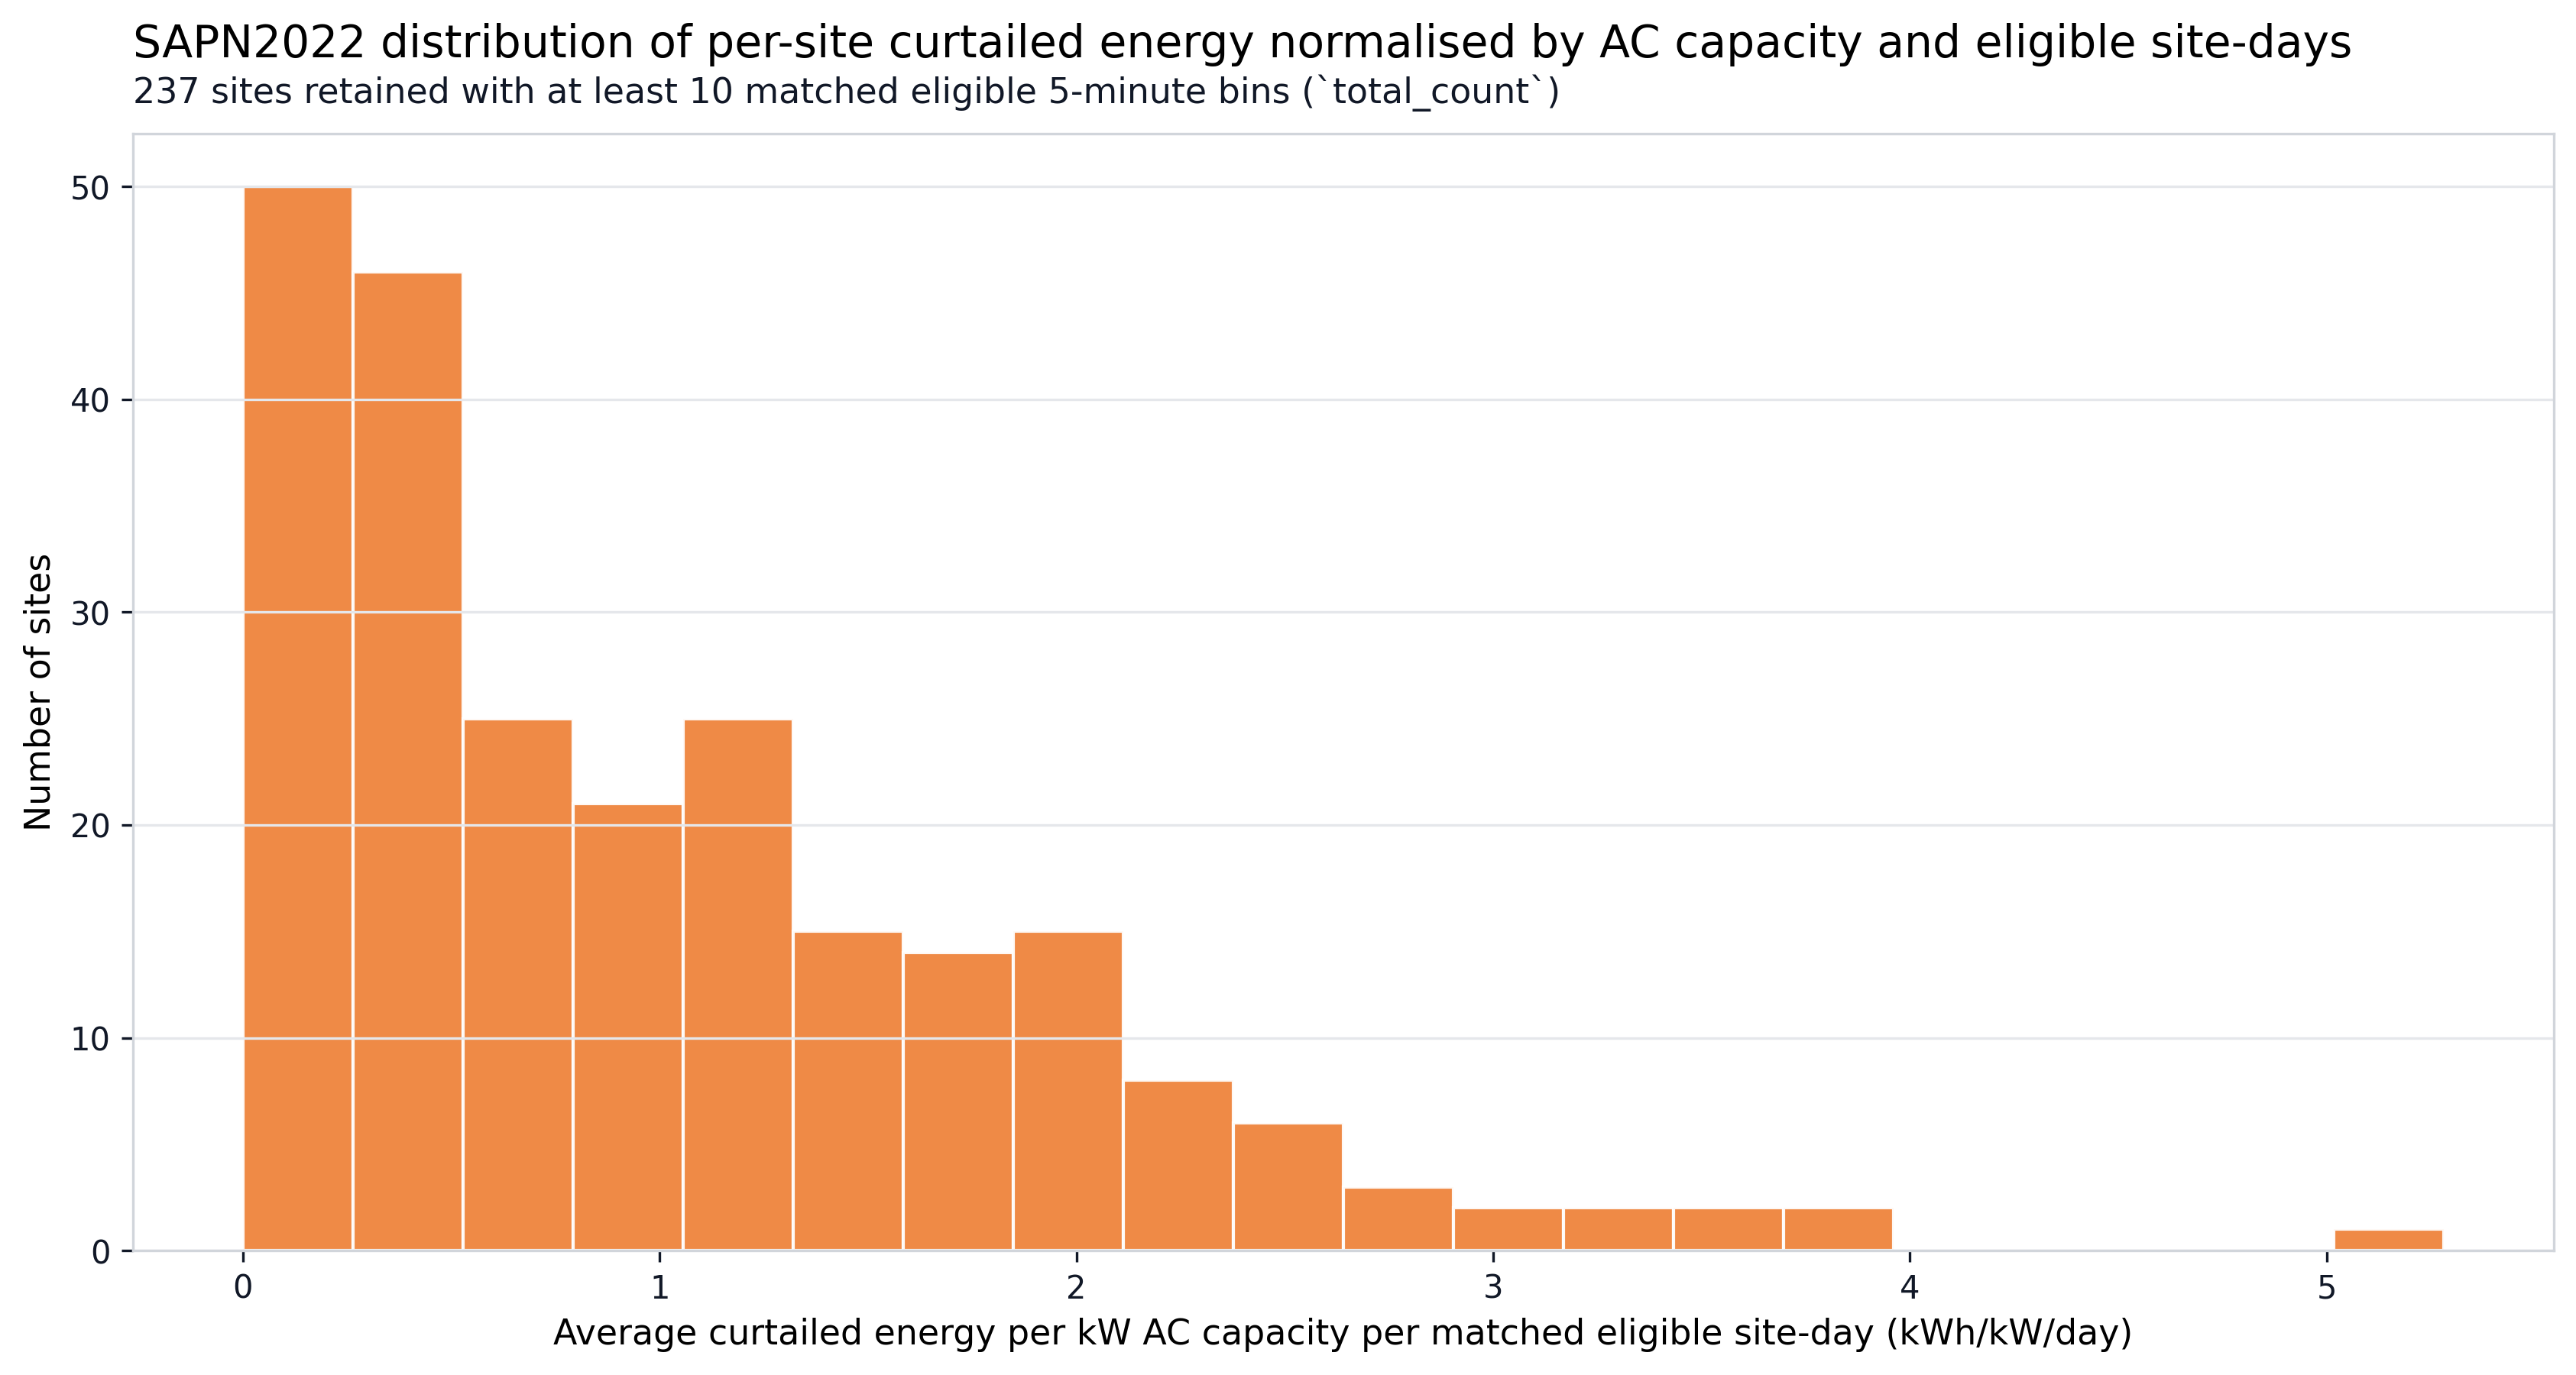

In [55]:
# Name the output file here so it is easy to change before calling the function.
# Input files used to build site_curtailment_kwh_per_kw_day_df in the prep cell above:
# - kwh_per_kw_day_summary_path: curtailment_sapn2022_5m.parquet
# - kwh_per_kw_day_structured_path: structured_data_5m.parquet
kwh_per_kw_day_hist_filename = "curtailment_sapn2022_site_kwh_per_kw_day_histogram.png"
min_matched_eligible_bins    = 10

fig_kwh_per_kw_day_hist, ax_kwh_per_kw_day_hist = plot_site_curtailment_kwh_per_kw_day_histogram(
    plot_df=site_curtailment_kwh_per_kw_day_df,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=kwh_per_kw_day_hist_filename,
    min_matched_eligible_bins=min_matched_eligible_bins,
    bins=20,
    save=False,
)
plt.show()


### plots for energy normlaised by AC capacity and number of eligible 5m timestamps
#### (where 5m bins exceed the LOS/ OV threshold)


In [56]:
def plot_site_curtailment_kwh_per_kw_time_bin_ranked(
    plot_df: pl.DataFrame,
    save_folder: Path,
    filename: str,
    min_matched_eligible_bins: int = 10,
    save: bool = False,
):
    """Plot one descending ranked `kWh/kW/bin` point per retained site."""
    save_folder = Path(save_folder)

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.scatter(
        plot_df["site_rank"].to_list(),
        plot_df["site_kwh_per_kw_per_time_bin"].to_list(),
        s=26,
        color=GRAFANA_CLASSIC_COLORS[4],
        edgecolors="white",
        linewidths=0.5,
        alpha=0.9,
    )

    ax.set_title(
        "SAPN2022 per-site curtailed energy normalised by AC capacity and eligible LOS/OV1 5-minute bins",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} sites retained with at least {min_matched_eligible_bins} matched eligible LOS/OV1 5-minute bins "
            "(`total_count`)"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel("Site rank", fontsize=11)
    ax.set_ylabel(
        "Normalied total energy curtailed (kWh/kW/5m bin)",
        fontsize=11,
    )
    ax.set_xlim(0.5, plot_df.height + 0.5)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


def plot_site_curtailment_kwh_per_kw_time_bin_histogram(
    plot_df: pl.DataFrame,
    save_folder: Path,
    filename: str,
    min_matched_eligible_bins: int = 10,
    bins: int | list[float] = 20,
    save: bool = False,
):
    """Plot a histogram of retained site `kWh/kW/bin` values."""
    save_folder = Path(save_folder)

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(
        plot_df["site_kwh_per_kw_per_time_bin"].to_list(),
        bins=bins,
        color=GRAFANA_CLASSIC_COLORS[5],
        edgecolor="white",
        linewidth=1.0,
        alpha=0.95,
    )

    ax.set_title(
        "SAPN2022 distribution of per-site curtailed energy normalised by AC capacity and eligible LOS/OV1 5-minute bins",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} sites retained with at least {min_matched_eligible_bins} matched eligible LOS/OV1 5-minute bins "
            "(`total_count`)"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel(
        "Average curtailed energy per kW AC capacity per matched eligible LOS/OV1 5-minute bin (kWh/kW/bin)",
        fontsize=11,
    )
    ax.set_ylabel("Number of sites", fontsize=11)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")
    
    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


### PLOT 2A - total energy curtailed normalised by system capacity and day (kWh/kW/bin)

This section reuses the same shared site-level base data as the `kWh/kW/day` plots.

But normalises by matched eligible LOS/OV1 5-minute bins instead of site-days.

Here, the per-bin denominator is `matched_eligible_bin_count = sum(total_count)` [curtailed and non-curtailed bins]. All eligible 5m bins where voltage exceeds LOS/ OV threshold. 


/var/folders/2m/0bhk_4qs61n2y1rtr16y0nxc0000gp/T/ipykernel_47548/1528702760.py:130: DeprecationWarning: `DataFrame.with_row_count` is deprecated; use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count("site_rank", offset=1)


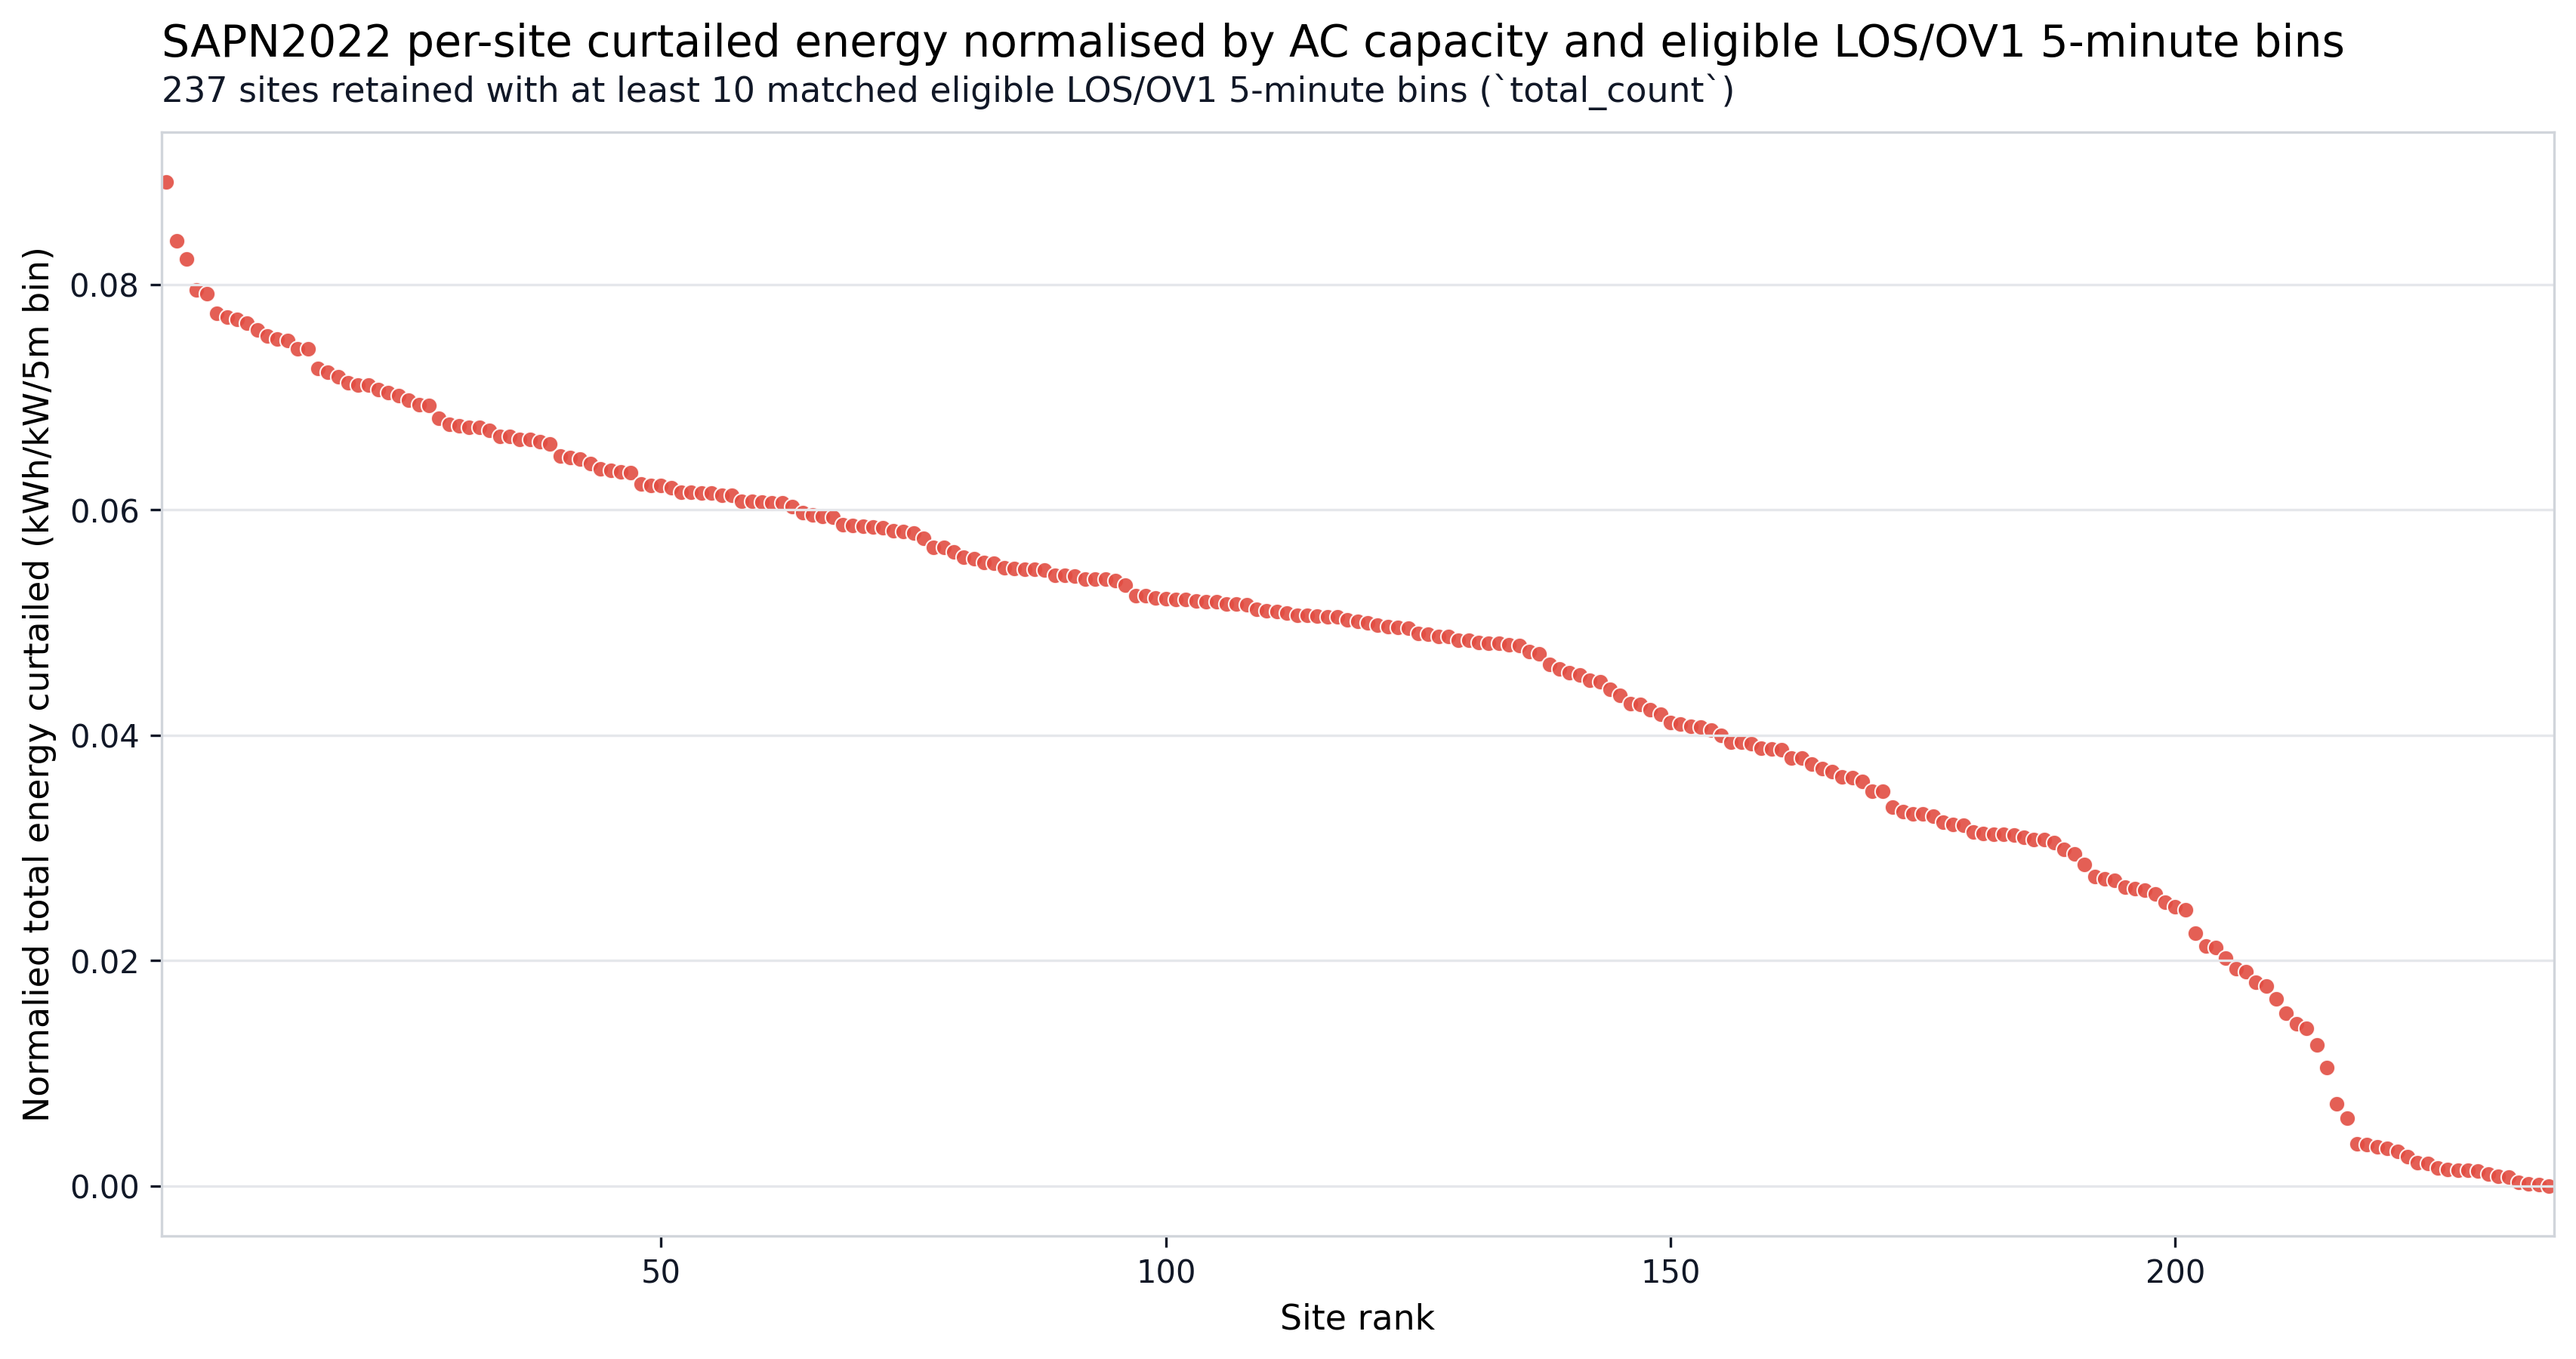

In [57]:
site_curtailment_kwh_per_kw_time_bin_df = _site_curtailment_kwh_per_kw_time_bin_plot_data(
    site_curtailment_kwh_per_kw_base_df
)

# Name the output file here so it is easy to change before calling the function.
# Input files used to build site_curtailment_kwh_per_kw_time_bin_df from the shared base prep:
# - kwh_per_kw_day_summary_path: curtailment_sapn2022_5m.parquet
# - kwh_per_kw_day_structured_path: structured_data_5m.parquet
kwh_per_kw_time_bin_ranked_filename = "curtailment_sapn2022_site_kwh_per_kw_time_bin_ranked.png"

fig_kwh_per_kw_time_bin_ranked, ax_kwh_per_kw_time_bin_ranked = plot_site_curtailment_kwh_per_kw_time_bin_ranked(
    plot_df=site_curtailment_kwh_per_kw_time_bin_df,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=kwh_per_kw_time_bin_ranked_filename,
    min_matched_eligible_bins=min_matched_eligible_bins,
    save=False,
)
plt.show()


### PLOT 2B - total energy curtailed normalised by system capacity and day (kWh/kW/bin) Histogram

This section reuses the same retained site-level `kWh/kW/bin` values as the ranked dot plot.

It groups them into bins so the x-axis is average curtailed energy per kW AC capacity per matched eligible LOS/OV1 5-minute bin and the y-axis is number of sites.

The same support filter based on `total_count` is kept for consistency with the ranked plot.


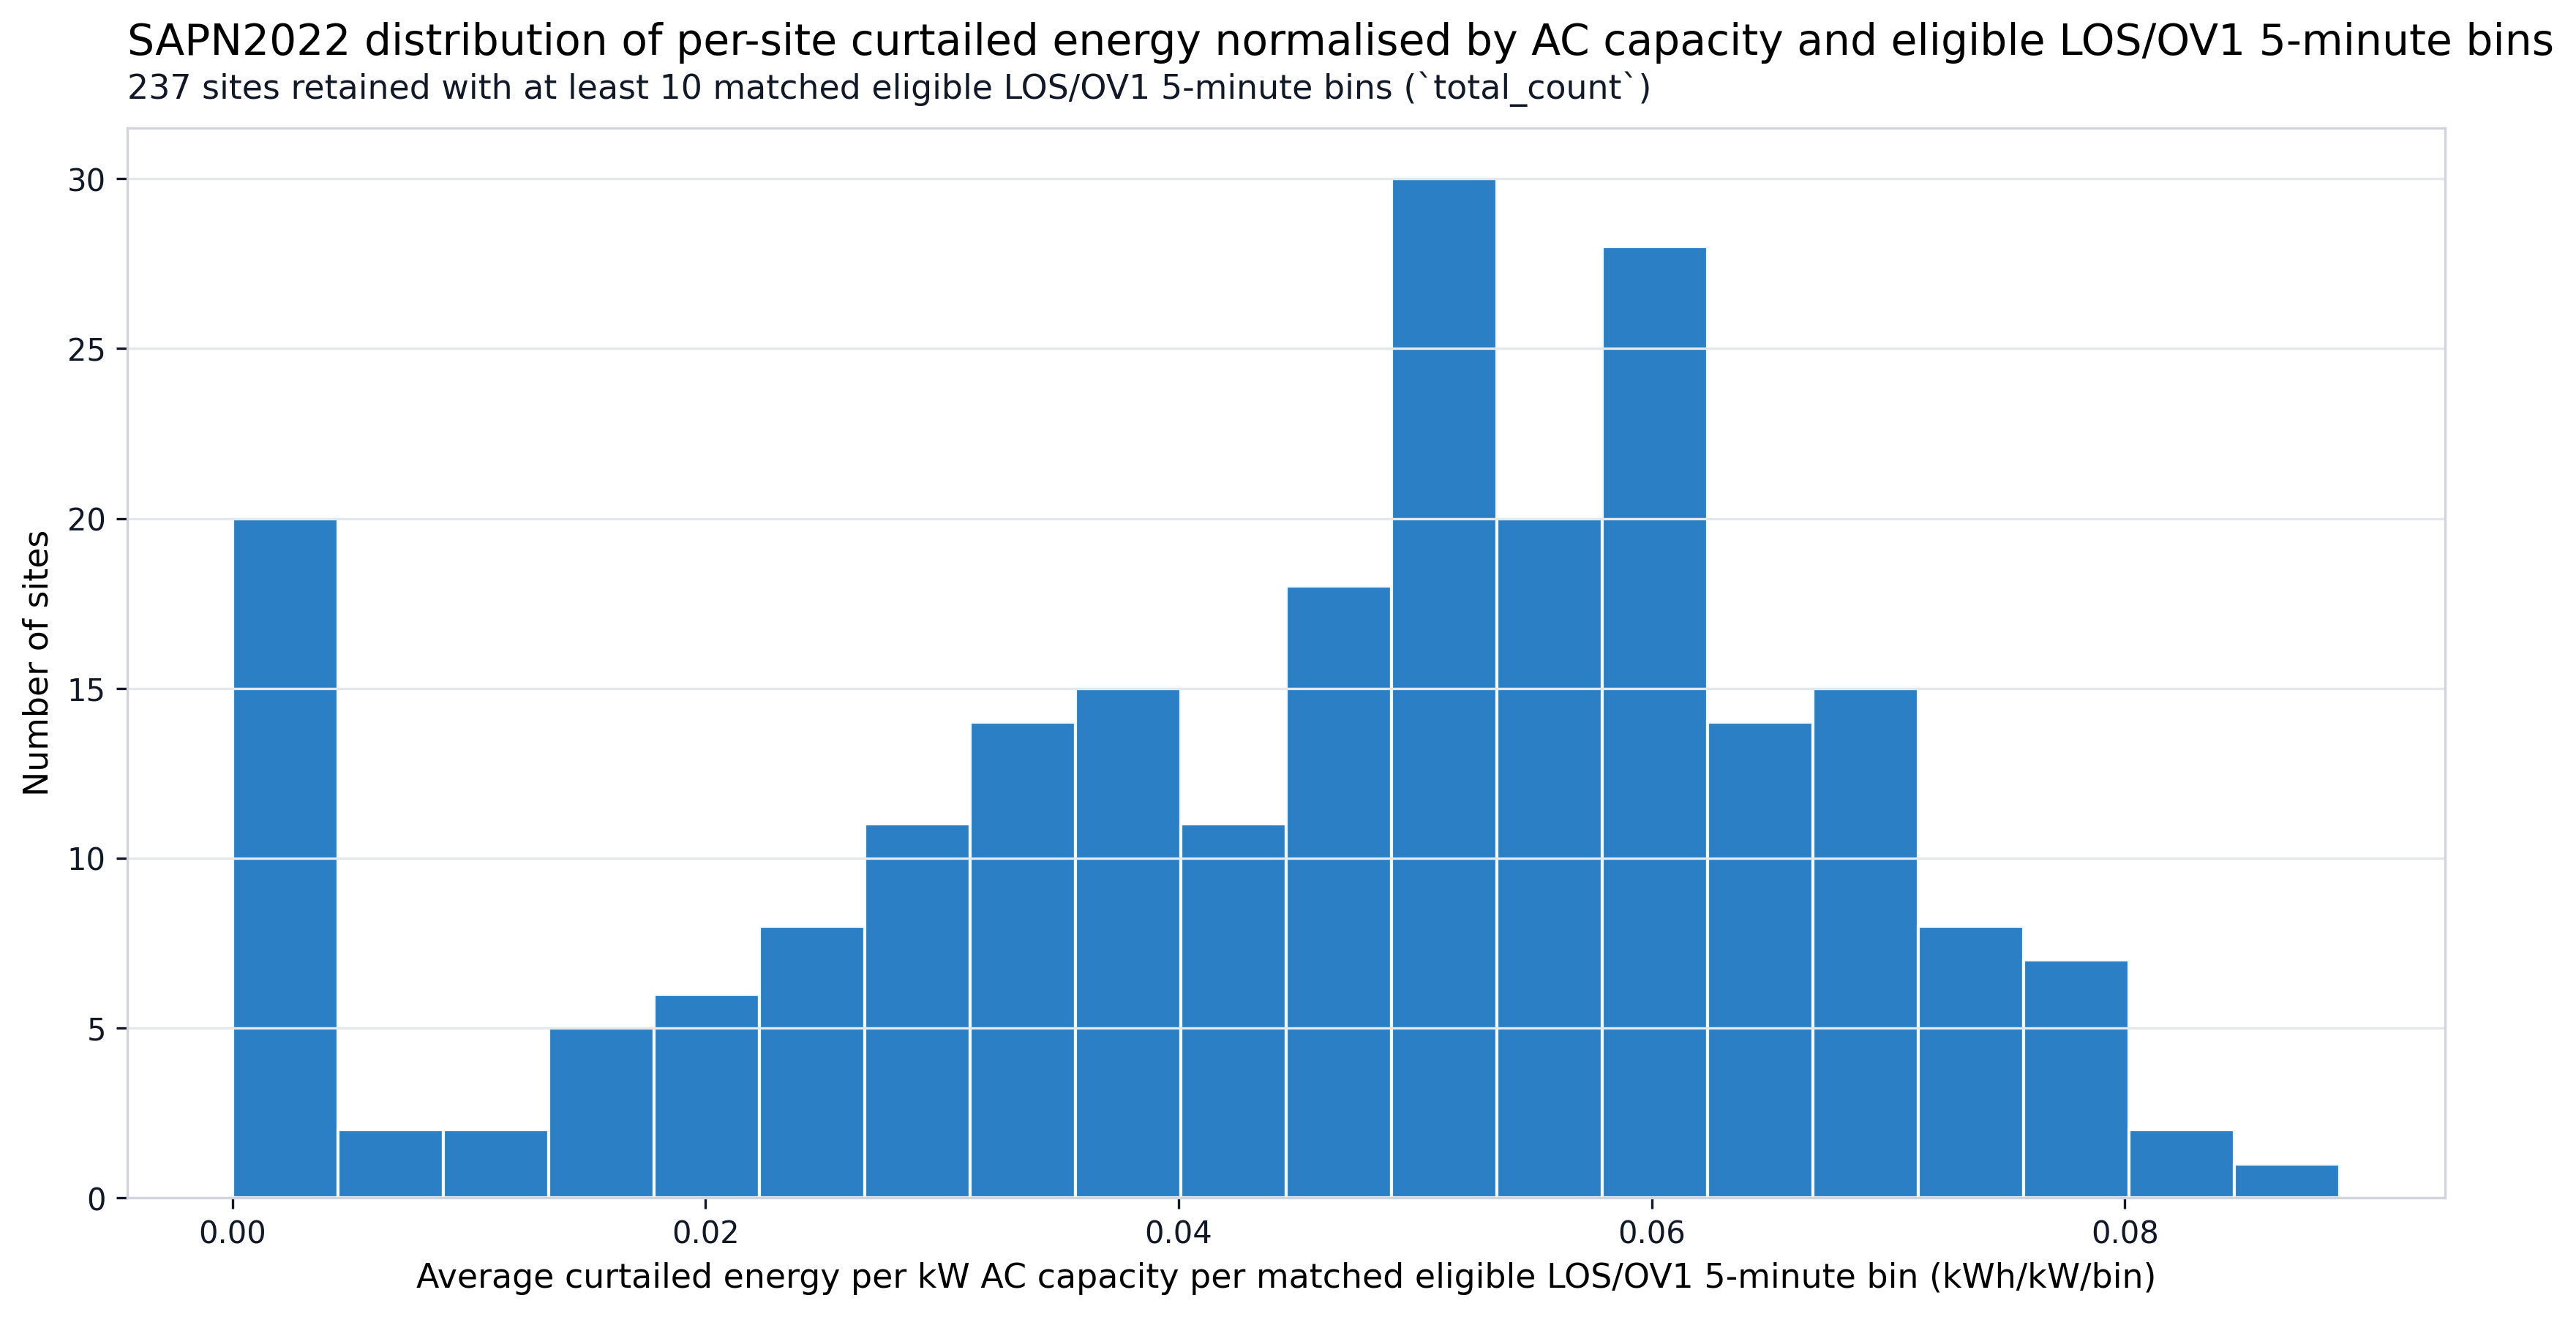

In [58]:
# Name the output file here so it is easy to change before calling the function.
# Input files used to build site_curtailment_kwh_per_kw_time_bin_df from the shared base prep:
# - kwh_per_kw_day_summary_path: curtailment_sapn2022_5m.parquet
# - kwh_per_kw_day_structured_path: structured_data_5m.parquet
kwh_per_kw_time_bin_hist_filename = "curtailment_sapn2022_site_kwh_per_kw_time_bin_histogram.png"

fig_kwh_per_kw_time_bin_hist, ax_kwh_per_kw_time_bin_hist = plot_site_curtailment_kwh_per_kw_time_bin_histogram(
    plot_df=site_curtailment_kwh_per_kw_time_bin_df,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=kwh_per_kw_time_bin_hist_filename,
    min_matched_eligible_bins=min_matched_eligible_bins,
    bins=20,
    save=False,
)
plt.show()


## Per-site conformance percentage ranked dot plot

This section uses the tier-based Phase B site summary to calculate, per assessed site, the percentage of responsible `LOS/OV1` timestamps that were compliant. 

Each retained site is shown as one point after filtering to sites with at least a chosen number of responsible `LOS/OV1` timestamps.


In [59]:
# Change these inputs here before generating the per-site conformance plots.
compliance_summary_path = DEFAULT_PHASE_B_SITE_SUMMARY
min_responsible_timestamps = 10

site_compliance_df = (
    pl.read_csv(compliance_summary_path, null_values=[""])
    .filter(pl.col("overall_pass").is_not_null())
    .with_columns([
        (pl.col("los_eligible") + pl.col("ov1_eligible")).alias("responsible_count"),
        (pl.col("los_compliant") + pl.col("ov1_compliant")).alias("compliant_count"),
    ])
    .filter(pl.col("responsible_count") > 0)
    .with_columns(
        (pl.col("compliant_count") / pl.col("responsible_count") * 100.0).alias("compliance_pct")
    )
    .filter(pl.col("responsible_count") >= min_responsible_timestamps)
    .sort(["compliance_pct", "site_id"], descending=[True, False])
    .with_row_count("site_rank", offset=1)
)

if site_compliance_df.is_empty():
    raise ValueError(
        "No assessed sites remain after applying the minimum responsible timestamp filter."
    )

site_compliance_df.select([
    pl.len().alias("retained_sites"),
    pl.col("responsible_count").min().alias("min_responsible_count"),
    pl.col("responsible_count").max().alias("max_responsible_count"),
    pl.col("compliance_pct").min().alias("min_compliance_pct"),
    pl.col("compliance_pct").max().alias("max_compliance_pct"),
])


/var/folders/2m/0bhk_4qs61n2y1rtr16y0nxc0000gp/T/ipykernel_47548/3574630464.py:18: DeprecationWarning: `DataFrame.with_row_count` is deprecated; use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count("site_rank", offset=1)


retained_sites,min_responsible_count,max_responsible_count,min_compliance_pct,max_compliance_pct
u32,i64,i64,f64,f64
336,10,7624,0.0,100.0


In [60]:
def plot_site_compliance_pct_ranked(
    plot_df: pl.DataFrame,
    save_folder: Path,
    filename: str,
    min_responsible_timestamps: int = 10,
    save: bool = False,
):
    """Plot one descending ranked conformance-percentage point per retained site."""
    save_folder = Path(save_folder)

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.scatter(
        plot_df["site_rank"].to_list(),
        plot_df["compliance_pct"].to_list(),
        s=26,
        color=GRAFANA_CLASSIC_COLORS[5],
        edgecolors="white",
        linewidths=0.5,
        alpha=0.9,
    )

    ax.set_title(
        "SAPN2022 per-site conformance percentage across responsible LOS/OV1 timestamps",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} assessed sites retained with at least "
            f"{min_responsible_timestamps} responsible LOS/OV1 timestamps"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel("Site rank", fontsize=11)
    ax.set_ylabel(
        "Responsible LOS/OV1 timestamps compliant, per site (%)",
        fontsize=11,
    )
    ax.set_xlim(0.5, plot_df.height + 0.5)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


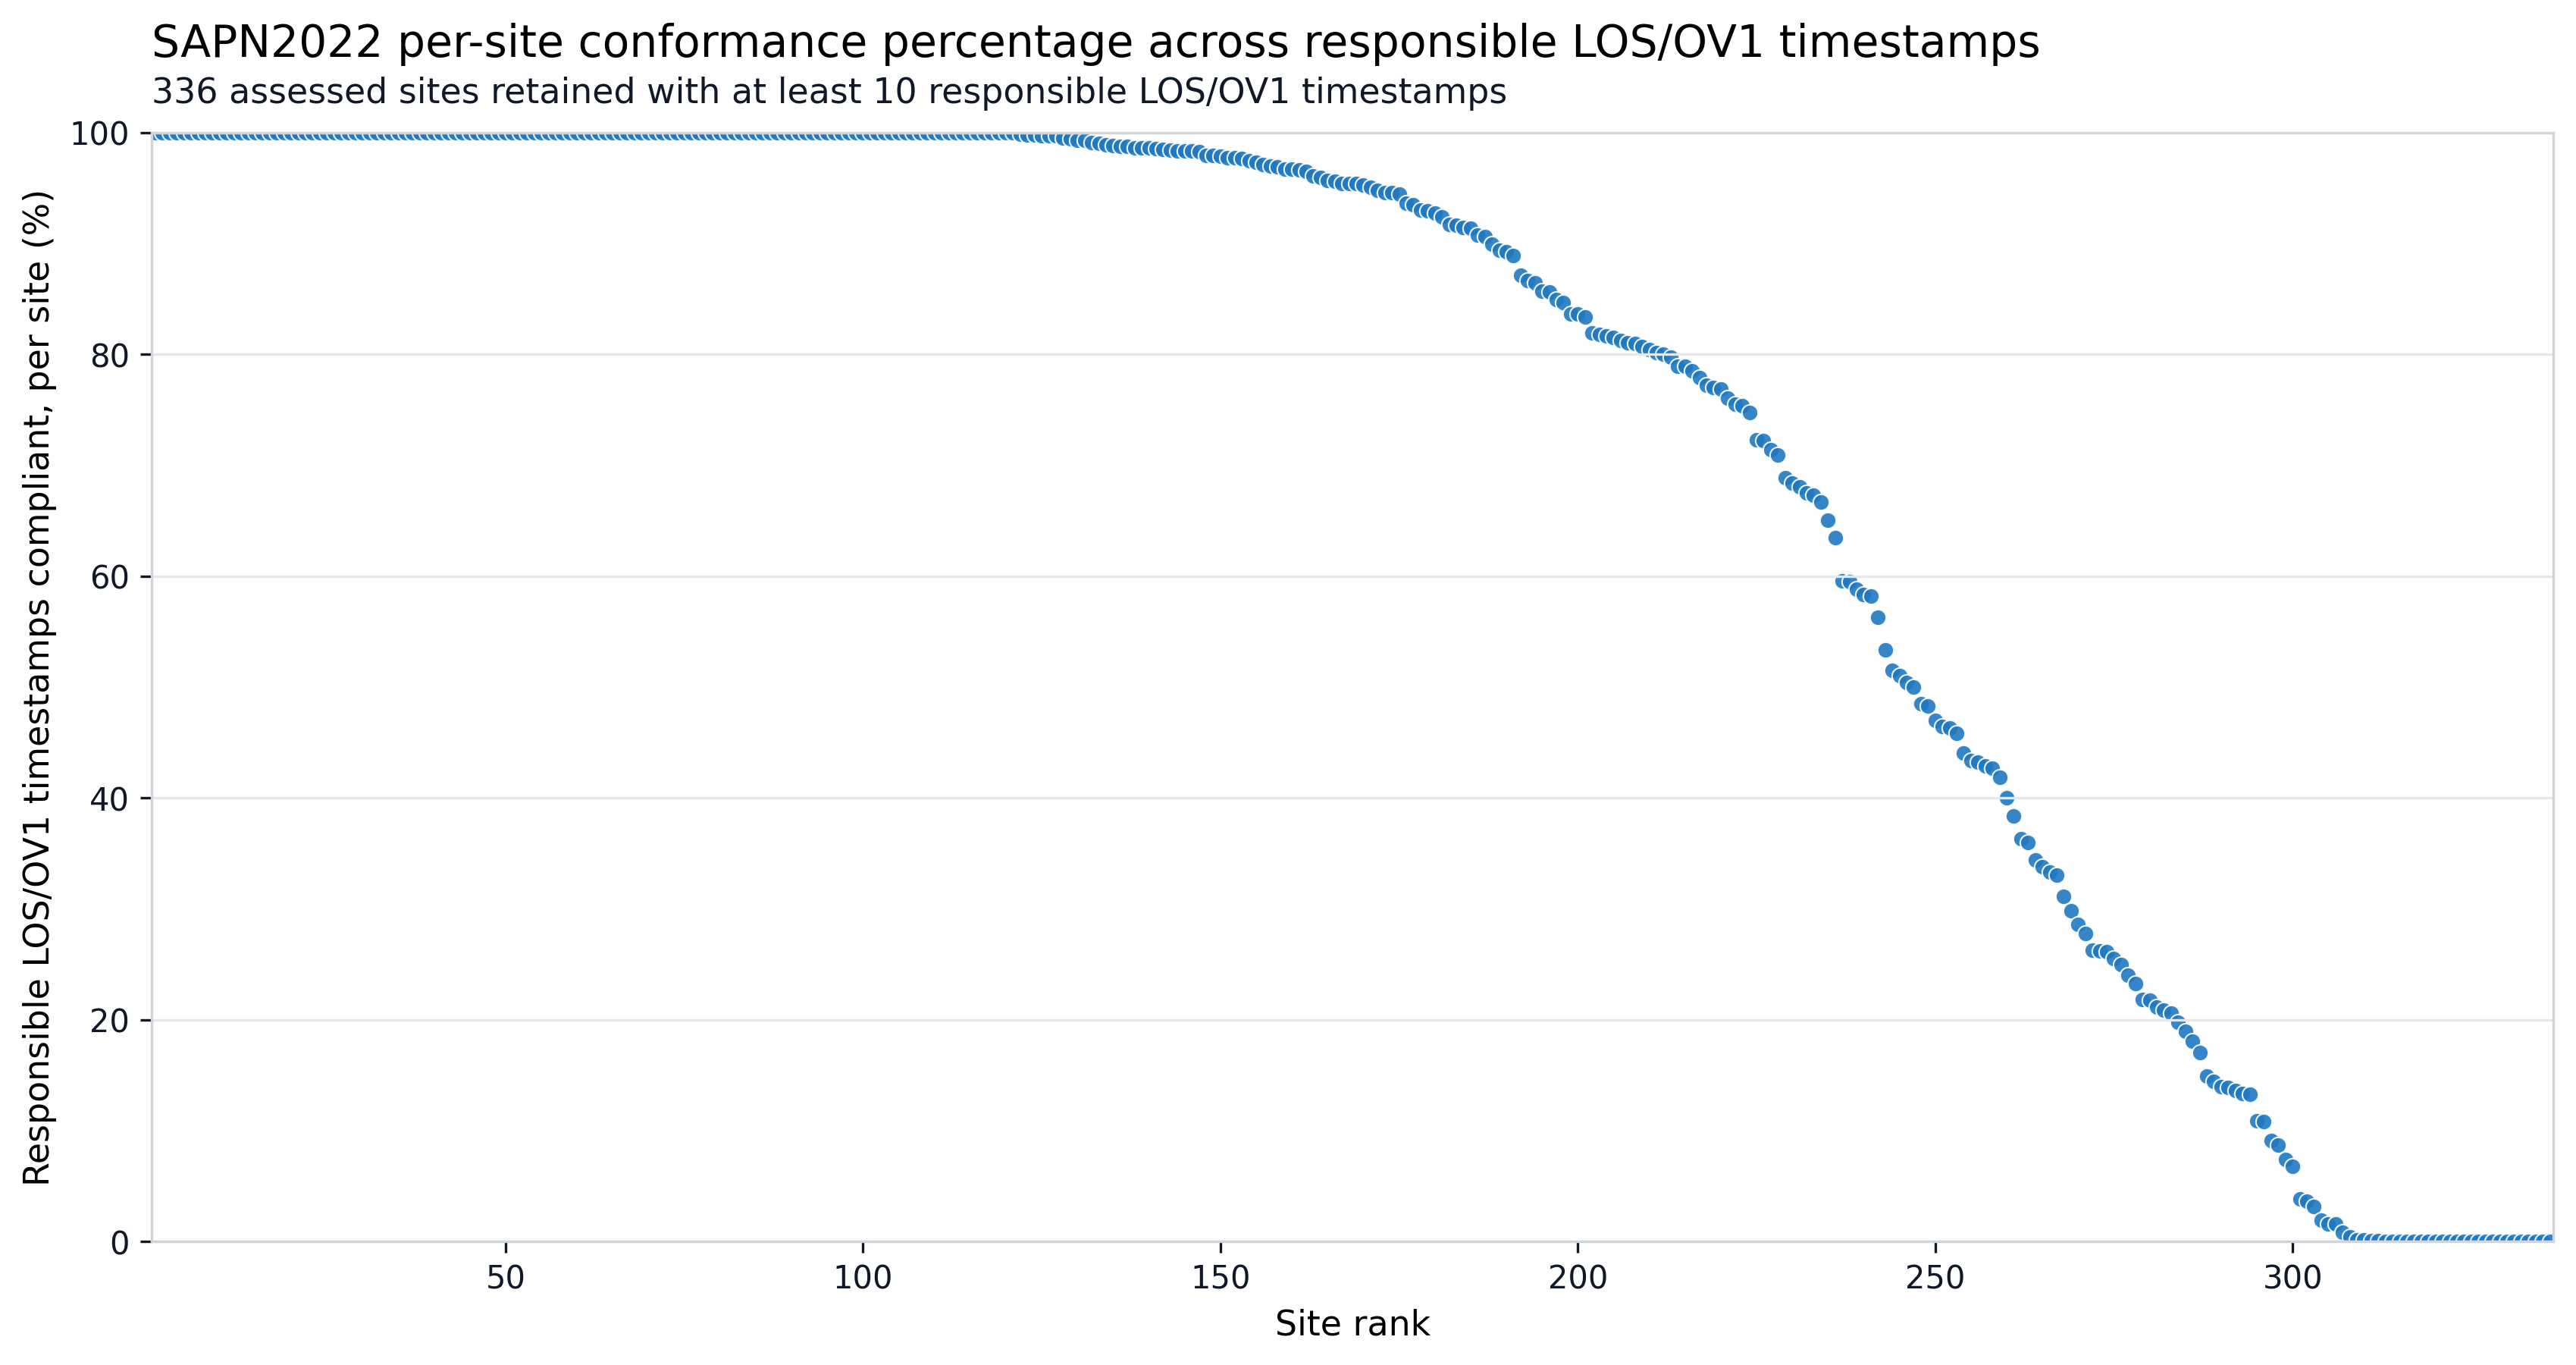

In [61]:
# Name the output file here so it is easy to change before calling the function.
# Input file used to build site_compliance_df in the prep cell above:
# - compliance_ranked_summary_path: phase_b_site_summary.csv
compliance_ranked_summary_path = DEFAULT_PHASE_B_SITE_SUMMARY
compliance_ranked_filename = "conformance_sapn2022_site_compliance_pct_ranked.png"

fig_compliance_ranked, ax_compliance_ranked = plot_site_compliance_pct_ranked(
    plot_df=site_compliance_df,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=compliance_ranked_filename,
    min_responsible_timestamps=min_responsible_timestamps,
    save=False,
)
plt.show()


## Per-site conformance percentage histogram

This section reuses the same retained site-level responsible-timestamp conformance percentages as the ranked dot plot,
but groups them into bins so the x-axis is per-site conformance percentage across responsible LOS/OV1 timestamps and the y-axis is number of sites.
The displayed percentage axis runs from high to low to match the current notebook style.


In [62]:
def plot_site_compliance_pct_histogram(
    plot_df: pl.DataFrame,
    save_folder: Path,
    filename: str,
    min_responsible_timestamps: int = 10,
    bins: int | list[float] = 20,
    save: bool = False,
):
    """Plot a histogram of retained site conformance percentages."""
    save_folder = Path(save_folder)

    fig, ax = plt.subplots(figsize=(12.0, 6.5), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(
        plot_df["compliance_pct"].to_list(),
        bins=bins,
        color=GRAFANA_CLASSIC_COLORS[1],
        edgecolor="white",
        linewidth=1.0,
        alpha=0.95,
    )

    ax.set_title(
        "SAPN2022 distribution of per-site conformance percentages across responsible LOS/OV1 timestamps",
        fontsize=14,
        loc="left",
        pad=24,
    )
    ax.text(
        0.0,
        1.02,
        (
            f"{plot_df.height} assessed sites retained with at least "
            f"{min_responsible_timestamps} responsible LOS/OV1 timestamps"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=TEXT_COLOR,
    )

    ax.set_xlabel(
        "Responsible LOS/OV1 timestamps compliant, per site (%)",
        fontsize=11,
    )
    ax.set_ylabel("Number of sites", fontsize=11)
    ax.set_xlim(100, 0)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", labelsize=10, colors=TEXT_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")

    fig.subplots_adjust(left=0.10, right=0.98, top=0.87, bottom=0.12)

    if save:
        output_path = save_folder / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig, ax


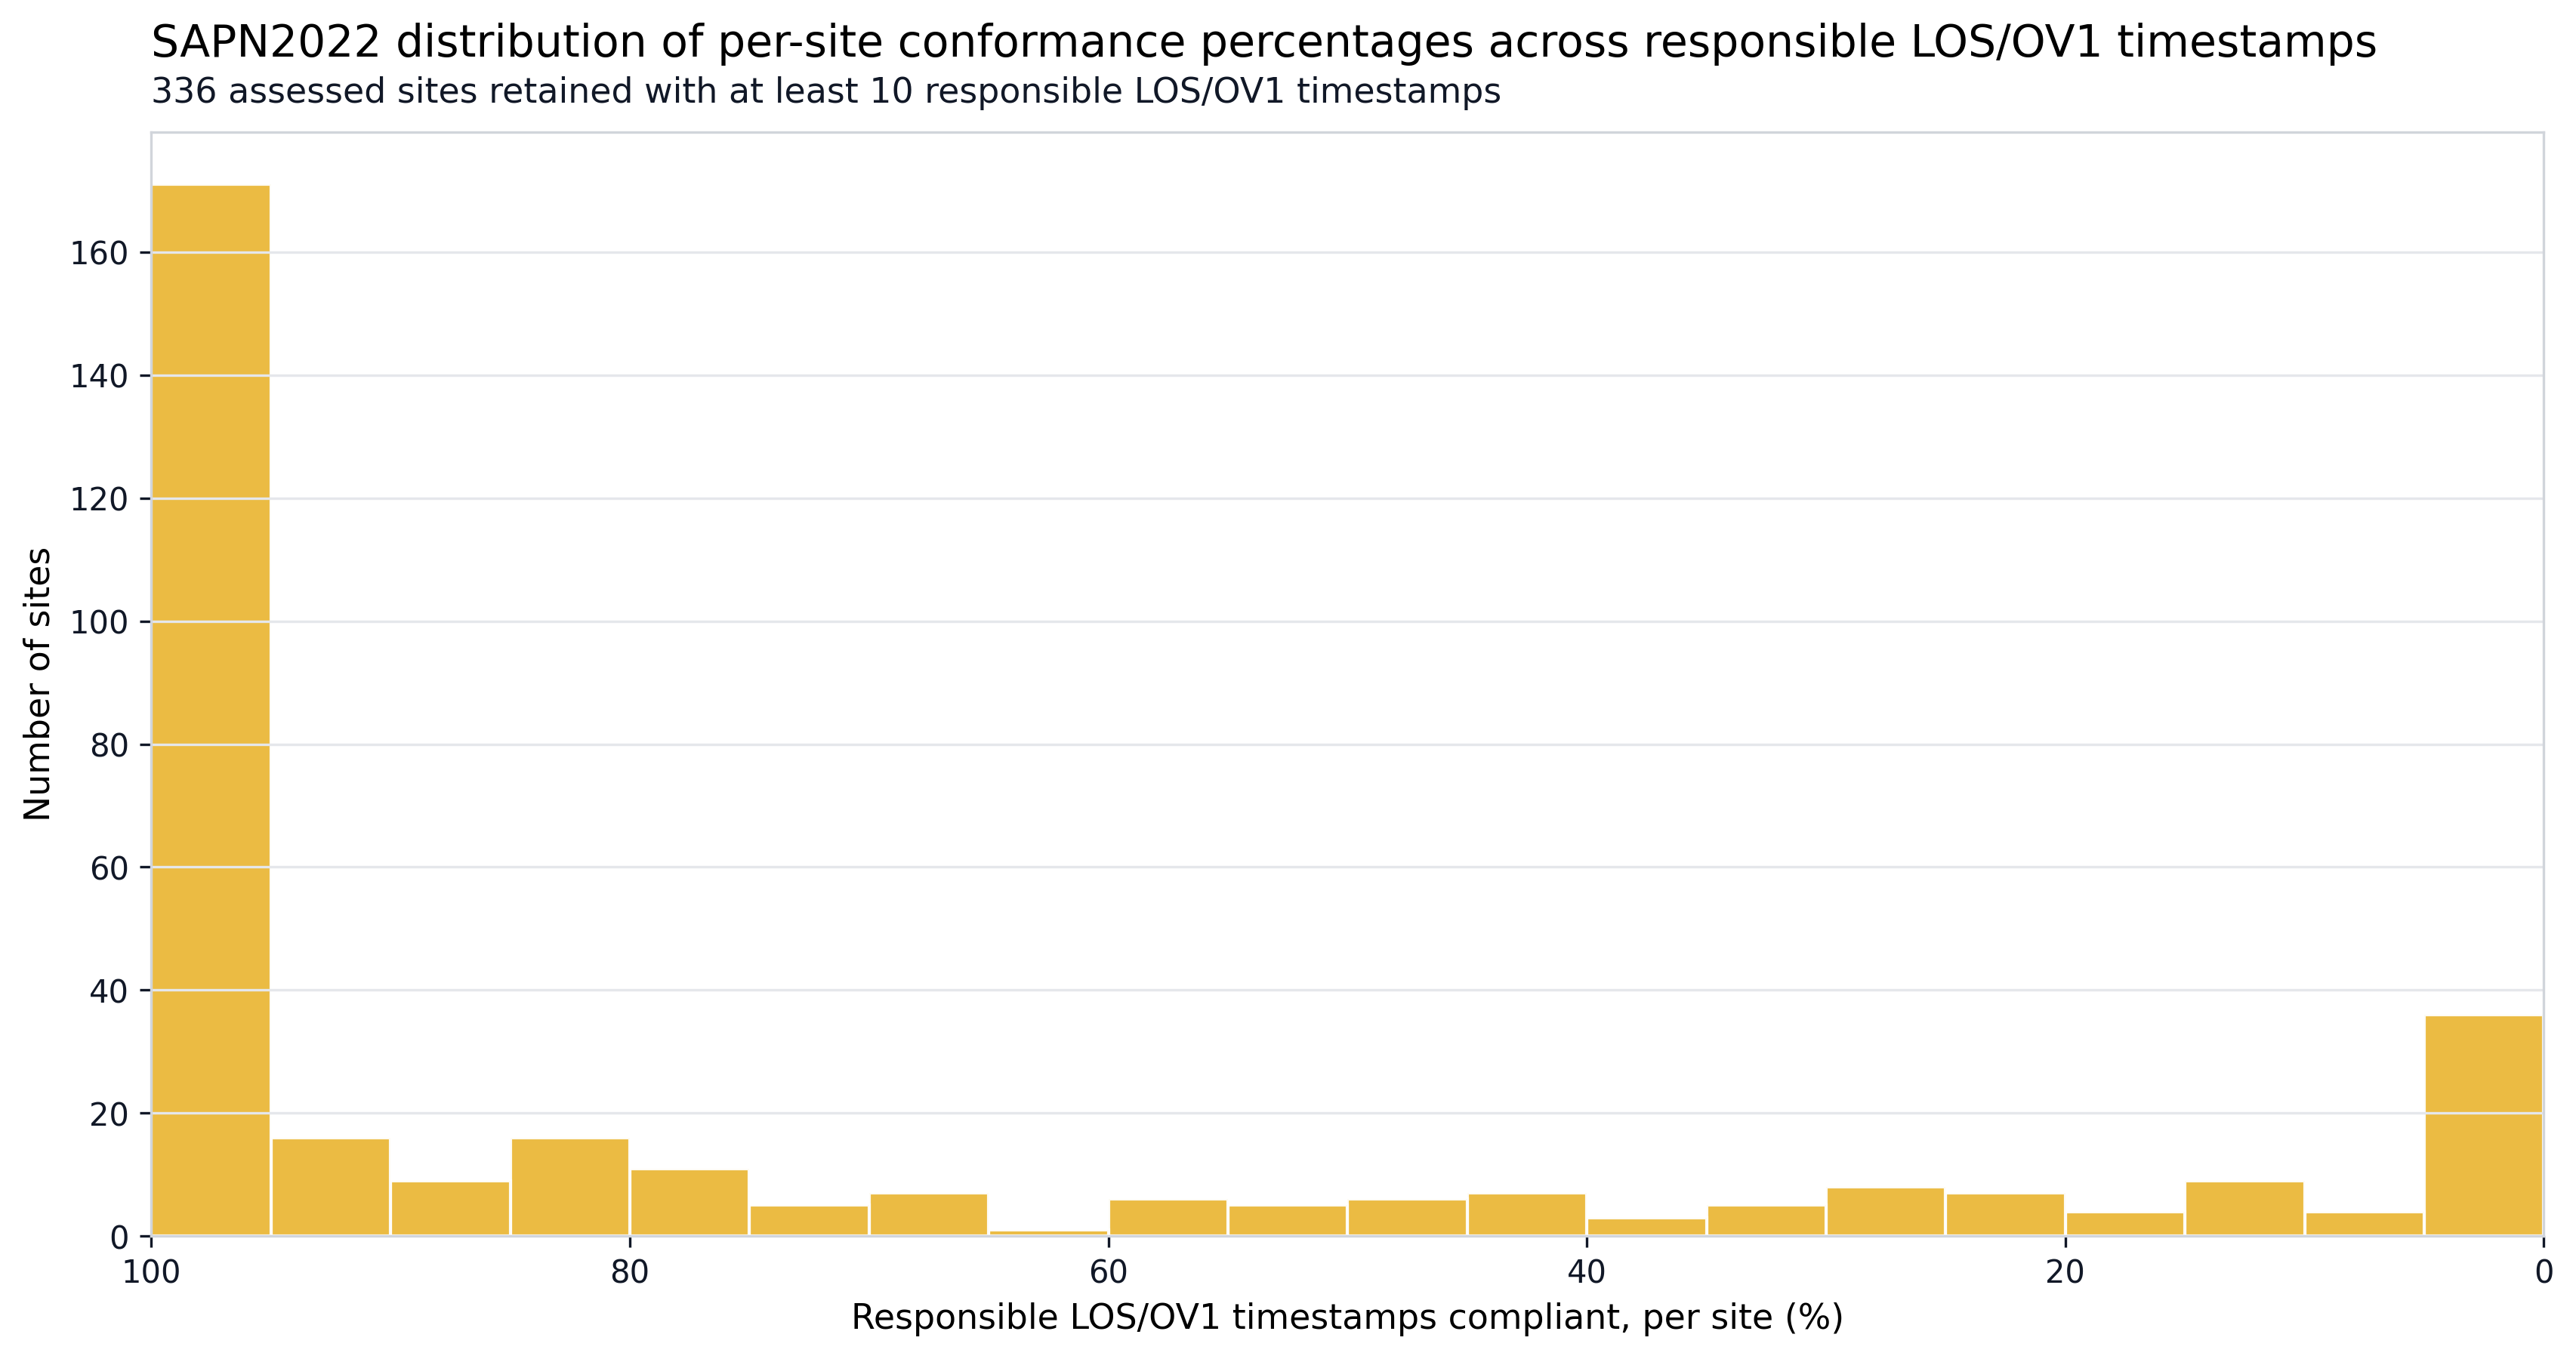

In [63]:
# Name the output file here so it is easy to change before calling the function.
# Input file used to build site_compliance_df in the prep cell above:
# - compliance_hist_summary_path: phase_b_site_summary.csv
# This conformance plot uses the higher-resolution site summary data.
compliance_hist_summary_path = DEFAULT_PHASE_B_SITE_SUMMARY
compliance_hist_filename     = "conformance_sapn2022_site_compliance_pct_histogram.png"

fig_compliance_hist, ax_compliance_hist = plot_site_compliance_pct_histogram(
    plot_df=site_compliance_df,
    save_folder=DEFAULT_folder_SAVE_PATH,
    filename=compliance_hist_filename,
    min_responsible_timestamps=min_responsible_timestamps,
    bins=20,
    save=False,
)
plt.show()
